> ✅ **BẢN V5 — đã trỏ dữ liệu sang nhánh v5** bằng cell override ngay sau `load_config()`
> (chỉ đổi trong notebook, KHÔNG đụng config chung của srcs). Toàn bộ thí nghiệm chạy trên
> train + validation của v5 — không đụng tập test. Kết quả ghi ra `data/model/v5/05b_...`;
> hồ sơ lịch sử v4 vẫn nằm nguyên ở `data/model/v4/05b_thuc_nghiem_tham_so/`.

# Bước 05b: Thực nghiệm Chứng minh các Tham số Hardcode
Dự án: Tốt nghiệp - Energy Forecasting - Nhóm thực hiện: The Outliers

## 1. TỔNG QUAN VÀ MỤC TIÊU

Tài liệu `docs/2026_08_06_Chung_Minh_Toan_Bo_Tham_So_Hardcode.md` đã chứng minh các hằng số
bằng **lý thuyết** (vật lý khí quyển, tiêu chuẩn PVLIB/Sandia, các bài báo IEEE/MDPI).

Notebook này chứng minh bằng **thực nghiệm**: với mỗi tham số, ta quét qua nhiều giá trị,
train lại mô hình và đo WAPE thực tế, rồi lập bảng đối chiếu. Mục đích là trả lời được câu
hỏi của hội đồng *"tại sao lại chọn đúng con số đó?"* bằng số liệu đo được trên chính bộ
dữ liệu 42 trạm, chứ không chỉ bằng trích dẫn.

**Nguyên tắc:** mọi thí nghiệm đều chạy trên **tập validation**, tuyệt đối không đụng tập
test — tập test chỉ được mở duy nhất một lần ở notebook 07.

### Các tham số được thực nghiệm

| Tham số | Giá trị đang dùng | Nằm ở |
|---|---|---|
| `eps_elev` | 0.05 | `features.yaml` — ngưỡng sin(góc cao) coi là ban ngày |
| `clip_csi` | 1.5 | `features.yaml` — trần chỉ số trời quang khi downscale bức xạ |
| `k_target_max` | 1.5 | `train.yaml` — trần mục tiêu đã chuẩn hoá |
| `tran_cong_suat_he_so` | 1.02 | `train.yaml` — cho phép vượt trần công suất 2% |
| `he_so_trong_so_dinh` | 1.0 | `train.yaml` — tăng trọng số vùng đỉnh |
| `quantile_scale` | 0.99 | `features.yaml` — phân vị tính `site_scale` |


## 2. Import thư viện và nạp cấu hình pipeline

In [2]:
# Notebook nay THU NGHIEM tren chinh code pipeline dang chay, nen import thang tu do -
# neu chep lai code ra day thi thu nghiem se do mot ban sao, khong con y nghia chung minh.
import os
for _b in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS',
           'NUMEXPR_NUM_THREADS', 'VECLIB_MAXIMUM_THREADS'):
    os.environ.setdefault(_b, '6')

import copy
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

PIPELINE = Path('../../srcs/05_machine_learning/forcasting_pipeline').resolve()
sys.path.insert(0, str(PIPELINE))

from core.config import load_config
from core.context import Ctx
from core.paths import Paths
from core.lgbm import fit_an_toan, kiem_tra_gpu, them_tham_so_gpu
from core.metrics import compute_metrics
from stages import s08a_prepare, s08e_metrics_val

CFG_GOC = load_config()

# ── OVERRIDE V5 (notebook-local): tro duong dan sang nhanh v5 cua notebook ──
def _sang_v5(x):
    if isinstance(x, str):
        if 'v4_preprocessing' in x:
            return x
        return x.replace('v4_tai_lap', 'v5').replace('v4', 'v5')
    if isinstance(x, dict):
        return {k: _sang_v5(v) for k, v in x.items()}
    if isinstance(x, list):
        return [_sang_v5(v) for v in x]
    return x

_p = CFG_GOC.paths
_moi = _sang_v5(dict(_p)); _p.clear(); _p.update(_moi)
_p['mlmart_raw'] = 'data/mlmart_base/v4_preprocessing.parquet'
_p['mlmart_base'] = 'data/mlmart_base/v5_final_cleaned.parquet'
print(f"[V5 OVERRIDE] root={_p['root']} | version={_p['version']} | mlmart_base={_p['mlmart_base']}")

LOSS = 'mae'        # mo hinh vo dich cua NHANH NOTEBOOK v5 (chon o 06_4 tren validation)
HORIZON = 1
OUTPUT_DIR = '../../data/model/v5/05b_thuc_nghiem_tham_so'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Da nap cau hinh pipeline.")
print(f"- Loss thu nghiem : {LOSS} (h{HORIZON})")
print(f"- Thu muc ket qua : {OUTPUT_DIR}")
print(f"- Thiet bi        : {'GPU' if CFG_GOC.runtime['gpu']['use_gpu'] else 'CPU'}"
      f" | deterministic = {CFG_GOC.runtime['lightgbm'].get('deterministic')}")


[V5 OVERRIDE] root=data/model/v5 | version=v5 | mlmart_base=data/mlmart_base/v5_final_cleaned.parquet
Da nap cau hinh pipeline.
- Loss thu nghiem : mae (h1)
- Thu muc ket qua : ../../data/model/v5/05b_thuc_nghiem_tham_so
- Thiet bi        : CPU | deterministic = True


## 3. Hàm chạy một thí nghiệm

Mỗi thí nghiệm = đổi **đúng một** tham số trong cấu hình → dựng lại ma trận huấn luyện →
train → đo WAPE trên tập validation. Mọi thứ khác giữ nguyên, nên chênh lệch WAPE quy được
về đúng tham số đang xét.

### Hai điều kiện bắt buộc để phép so sánh có giá trị

**(1) Dùng siêu tham số trung lập, không dùng kết quả Optuna.**
Bộ siêu tham số trong `best_params.json` được Optuna tìm ra **trong khi các hằng số đang
mang giá trị hiện tại**. Nếu dùng nó để chấm điểm các giá trị khác thì giá trị đang dùng
được lợi thế sẵn: siêu tham số đã tối ưu riêng cho nó. Vì vậy mọi thí nghiệm ở đây đều dùng
`default_params` trong `train.yaml` — cùng một bộ cho tất cả, không giá trị nào được ưu ái.

**(2) Cố định phạm vi đánh giá.**
Riêng `eps_elev` vừa quyết định dòng nào vào tập train, vừa quyết định dòng nào được chấm
điểm. Ngưỡng càng cao thì càng cắt bớt vùng bình minh/hoàng hôn — vốn là vùng khó dự báo
nhất — nên WAPE đẹp lên do bài toán dễ đi chứ không phải do mô hình tốt hơn. Để so được,
phần đo luôn dùng **ngưỡng gốc** (`EPS_CHUAN`), chỉ phần huấn luyện mới đổi theo giá trị
đang thử.

In [3]:
EPS_CHUAN = float(CFG_GOC.features['eps_elev'])   # nguong dung de CO DINH pham vi do


def chay_1_thi_nghiem(duong_dan_khoa, gia_tri, nhan=''):
    """Doi DUNG MOT tham so roi train lai, tra ve dict ket qua.

    duong_dan_khoa: vd ('features', 'eps_elev') hoac ('train', 'k_target_max')
    """
    cfg = copy.deepcopy(CFG_GOC)
    phan, khoa = duong_dan_khoa
    goc = getattr(cfg, phan)[khoa]
    getattr(cfg, phan)[khoa] = gia_tri

    # (1) Tat Optuna: moi thi nghiem dung chung default_params -> khong gia tri nao duoc
    #     loi the tu bo sieu tham so da tuning rieng cho no.
    cfg.train['use_best_params_if_exists'] = False

    ctx = Ctx(cfg=cfg, paths=Paths(cfg), loss_name=LOSS, horizon_steps=HORIZON)
    t0 = time.time()
    s08a_prepare.chuan_bi(ctx)

    gpu, _ = kiem_tra_gpu(cfg)
    tho, nguon_tham_so = cfg.sieu_tham_so(LOSS, HORIZON)
    ctx.model, _ = fit_an_toan(them_tham_so_gpu(tho, cfg, gpu), ctx.X_dev, ctx.y_dev,
                               sample_weight=ctx.w_dev, cfg=cfg)

    # (2) Do tren pham vi CO DINH: dung lai cfg voi eps_elev goc, chi phan train moi doi
    cfg_do = copy.deepcopy(cfg)
    cfg_do.features['eps_elev'] = EPS_CHUAN
    ctx_do = Ctx(cfg=cfg_do, paths=Paths(cfg_do), loss_name=LOSS, horizon_steps=HORIZON)
    ctx_do.model, ctx_do.features, ctx_do.medians = ctx.model, ctx.features, ctx.medians
    m = s08e_metrics_val.tinh_metrics_val_06_4(ctx_do)['measured_daylight']
    giay = time.time() - t0

    return {
        'tham_so': f'{phan}.{khoa}',
        'gia_tri': gia_tri,
        'la_dang_dung': gia_tri == goc,
        'ghi_chu': nhan,
        'nguon_tham_so': nguon_tham_so,
        'so_dong_train': int(ctx.X_dev.shape[0]),
        'so_dong_do': int(m['n']),
        'wape_val_%': round(m['wape'], 4),
        'rmse_val': round(m['rmse'], 4),
        'mae_val': round(m['mae'], 4),
        'r2_val': round(m['r2'], 4),
        'giay': round(giay, 1),
    }


def quet(duong_dan_khoa, cac_gia_tri, nhan_theo_gia_tri=None):
    """Quet mot tham so qua nhieu gia tri, in bang ket qua."""
    nhan_theo_gia_tri = nhan_theo_gia_tri or {}
    ds = []
    for v in cac_gia_tri:
        r = chay_1_thi_nghiem(duong_dan_khoa, v, nhan_theo_gia_tri.get(v, ''))
        danh_dau = '  <== DANG DUNG' if r['la_dang_dung'] else ''
        print(f"   {str(v):>8}: WAPE {r['wape_val_%']:.4f}%  "
              f"| train {r['so_dong_train']:>9,} dong | do {r['so_dong_do']:>9,} dong "
              f"| {r['giay']:.0f}s{danh_dau}")
        ds.append(r)
    bang = pd.DataFrame(ds)
    if len(bang) > 1 and bang['wape_val_%'].nunique() == 1:
        print("   [CANH BAO - KNOB CHET?] WAPE trung nhau o MOI gia tri quet ->")
        print("   tham so nay co the KHONG con nam trong duong tinh. Thi nghiem")
        print("   KHONG HOP LE cho toi khi xac minh knob duoc doc o stage nao (grep srcs).")
    if bang['so_dong_do'].nunique() != 1:
        print("   [CANH BAO] so dong DO khong bang nhau giua cac gia tri -> WAPE khong so"
              " sanh truc tiep duoc, phai co dinh lai pham vi do.")
    return bang


print("Da dinh nghia chay_1_thi_nghiem() va quet().")
print(f"- Sieu tham so : default_params (KHONG dung Optuna) - de moi gia tri duoc doi xu nhu nhau")
print(f"- Pham vi do   : co dinh o eps_elev = {EPS_CHUAN} cho MOI thi nghiem")
print("- Moi lan train mat khoang 30-40 giay, moi tham so quet 3-5 gia tri.")


def ve_quet(bang, ten):
    """Hinh tai cho cho mot thi nghiem quet: bar WAPE, do = dang dung, dai nhieu neu co TN10."""
    import os
    import matplotlib.pyplot as plt
    _m = ['#d62728' if x else '#4c72b0' for x in bang['la_dang_dung']]
    fig, ax = plt.subplots(figsize=(7.2, 3.6))
    ax.bar(range(len(bang)), bang['wape_val_%'], color=_m)
    ax.set_xticks(range(len(bang)))
    ax.set_xticklabels([str(v) for v in bang['gia_tri']])
    _lo, _hi = bang['wape_val_%'].min(), bang['wape_val_%'].max()
    _csv_tn10 = f'{OUTPUT_DIR}/tn10_nhieu_huan_luyen.csv'
    _chu = ''
    if os.path.exists(_csv_tn10):
        _sig = float(pd.read_csv(_csv_tn10)['wape_val_%'].std())
        _v0 = float(bang.loc[bang['la_dang_dung'], 'wape_val_%'].iloc[0])
        ax.axhspan(_v0 - 3 * _sig, _v0 + 3 * _sig, color='#95a5a6', alpha=0.25, zorder=0,
                   label='±3σ nhieu seed (TN10)')
        _lo = min(_lo, _v0 - 3 * _sig); _hi = max(_hi, _v0 + 3 * _sig)
        _d = bang['wape_val_%'].max() - bang['wape_val_%'].min()
        _chu = (' | trong dai nhieu -> KHONG NHAY' if _d < 3 * _sig
                else ' | vuot dai nhieu -> khac biet THAT')
        ax.legend(fontsize=8)
    for _i, _v in enumerate(bang['wape_val_%']):
        ax.text(_i, _v, f'{_v:.3f}', ha='center', va='bottom', fontsize=9)
    ax.set_ylim(_lo - (_hi - _lo) * 0.25 - 0.05, _hi + (_hi - _lo) * 0.15 + 0.05)
    ax.set_xlabel('Gia tri'); ax.set_ylabel('WAPE validation (%)')
    ax.set_title(f'Quet {ten} (do = dang dung){_chu}', fontsize=10)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/quet_{ten}.png', dpi=130, bbox_inches='tight')
    plt.show()

print("Da dinh nghia ve_quet() - hinh tai cho cho tung thi nghiem.")

Da dinh nghia chay_1_thi_nghiem() va quet().
- Sieu tham so : default_params (KHONG dung Optuna) - de moi gia tri duoc doi xu nhu nhau
- Pham vi do   : co dinh o eps_elev = 0.05 cho MOI thi nghiem
- Moi lan train mat khoang 30-40 giay, moi tham so quet 3-5 gia tri.
Da dinh nghia ve_quet() - hinh tai cho cho tung thi nghiem.


## 4. Thí nghiệm 1 — `eps_elev`: ngưỡng phân định ngày/đêm

`eps_elev` là ngưỡng `sin(góc cao mặt trời)` để coi một thời điểm là ban ngày. Dòng dưới
ngưỡng bị loại khỏi tập huấn luyện (vì mục tiêu chuẩn hoá `k = energy / (site_scale × sin_el)`
không xác định khi `sin_el → 0`) và bị ép dự báo bằng 0 lúc suy luận.

- Đặt **quá thấp** → giữ lại các thời điểm tranh tối tranh sáng, mẫu số gần 0 làm `k` bùng nổ
- Đặt **quá cao** → cắt mất phần bình minh/hoàng hôn có sản lượng thật

--- THI NGHIEM 1: eps_elev ---
selected_features.json: 39 cot -> giu 39, bo 0 ([])
Loc v5_train_selected: 1,550,856 -> 1,441,104 dong (48 cot)
Loc v5_val_selected: 723,114 -> 668,714 dong (48 cot)
Them 14 dac trung tat dinh tai T+15 phut
Tong so dac trung: 53
Nguong cat suy tu tap train: phan vi 0.99 cua k = 1.3886
Tap validation rieng: 331,879 dong (chua tung tham gia fit, dung de chon mo hinh)
Ma tran train: 604,734 dong x 53 dac trung
Bi loai khoi ham muc tieu: 104,469/709,203 (14.73%)
Khoang thoi gian train: 2020-01-02 06:15:00 -> 2021-06-21 17:15:00
Tap test: KHONG mo o stage nay (chi mo o s09 sau khi da chon xong mo hinh)
   Loai site [19, 24]: 723,114 -> 688,680 dong
        0.0: WAPE 22.4695%  | train   604,734 dong | do   289,348 dong | 95s
selected_features.json: 39 cot -> giu 39, bo 0 ([])
Loc v5_train_selected: 1,550,856 -> 1,441,104 dong (48 cot)
Loc v5_val_selected: 723,114 -> 668,714 dong (48 cot)
Them 14 dac trung tat dinh tai T+15 phut
Tong so dac trung: 53
Nguong cat 

,tham_so,gia_tri,la_dang_dung,ghi_chu,nguon_tham_so,so_dong_train,so_dong_do,wape_val_%,rmse_val,mae_val,r2_val,giay
0,features.eps_elev,0.00,False,khong loc gi,train.yaml: default_params,604734,289348,22.4695,3.7138,1.5322,0.8960,95.4
1,features.eps_elev,0.02,False,,train.yaml: default_params,603419,289348,22.2748,3.6823,1.5189,0.8978,94.2
2,features.eps_elev,0.05,True,dang dung,train.yaml: default_params,599552,289348,22.2349,3.6810,1.5162,0.8979,87.8
3,features.eps_elev,0.10,False,,train.yaml: default_params,582120,289348,22.2282,3.6861,1.5158,0.8976,90.5
4,features.eps_elev,0.15,False,cat ca binh minh/hoang hon,train.yaml: default_params,557014,289348,22.3004,3.6744,1.5207,0.8982,86.8


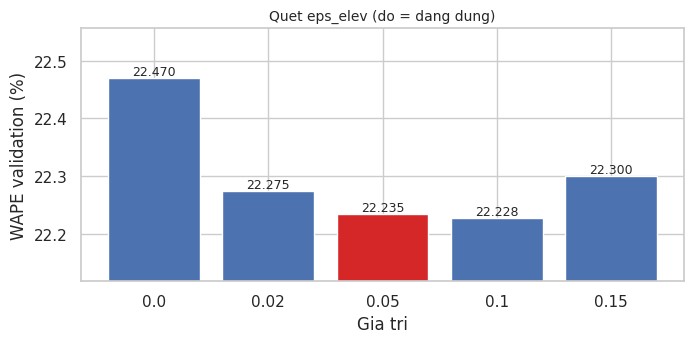

In [4]:
print("--- THI NGHIEM 1: eps_elev ---")
kq_eps = quet(('features', 'eps_elev'), [0.0, 0.02, 0.05, 0.10, 0.15],
              {0.0: 'khong loc gi', 0.05: 'dang dung', 0.15: 'cat ca binh minh/hoang hon'})
display(kq_eps)

ve_quet(kq_eps, 'eps_elev')

## 5. Thí nghiệm 2 — trần cắt nhãn: chọn MỨC PHÂN VỊ `clip_phan_vi`

Trần cắt nhãn của pipeline **không phải hằng số**: nó được suy từ dữ liệu bằng
`trần = phân_vị(k_train, clip_phan_vi)` với `clip_phan_vi = 0.99` (train.yaml).
(Hằng số 1.5 cũ đã bị loại khỏi đường tính từ fix 2026-08-13 — chỉ còn là fallback,
kiểm chứng inert ghi trong nhật ký.)

**Thí nghiệm:** quét chính tham số sống `clip_phan_vi` qua các mức, TRAIN LẠI từ đầu ở
mỗi mức — bao gồm mức **1.00 = không cắt nhãn nào** làm đối chứng cho câu hỏi "cắt có
oan không": nếu không cắt mà tốt hơn thì mức 1.00 phải thắng.

TN6 phía dưới đối chiếu chéo cùng câu hỏi bằng phương pháp rẻ hơn (một model dự báo k
thô, cắt ở từng mức khi chấm) — hai phương pháp phải cho cùng xu hướng.

In [5]:
print("--- THI NGHIEM 2: clip_phan_vi (muc phan vi suy tran cat nhan) ---")
kq_k = quet(('train', 'clip_phan_vi'), [0.90, 0.95, 0.99, 0.995, 1.00],
            {0.99: 'dang dung', 1.00: 'KHONG cat nhan nao (doi chung)'})
display(kq_k)

--- THI NGHIEM 2: clip_phan_vi (muc phan vi suy tran cat nhan) ---
selected_features.json: 39 cot -> giu 39, bo 0 ([])
Loc v5_train_selected: 1,550,856 -> 1,441,104 dong (48 cot)
Loc v5_val_selected: 723,114 -> 668,714 dong (48 cot)
Them 14 dac trung tat dinh tai T+15 phut
Tong so dac trung: 53
Nguong cat suy tu tap train: phan vi 0.9 cua k = 1.1427
Tap validation rieng: 318,553 dong (chua tung tham gia fit, dung de chon mo hinh)
Ma tran train: 599,552 dong x 53 dac trung
Bi loai khoi ham muc tieu: 81,196/680,748 (11.93%)
Khoang thoi gian train: 2020-01-02 06:30:00 -> 2021-06-21 17:00:00
Tap test: KHONG mo o stage nay (chi mo o s09 sau khi da chon xong mo hinh)
   Loai site [19, 24]: 723,114 -> 688,680 dong
        0.9: WAPE 22.6875%  | train   599,552 dong | do   289,348 dong | 93s
selected_features.json: 39 cot -> giu 39, bo 0 ([])
Loc v5_train_selected: 1,550,856 -> 1,441,104 dong (48 cot)
Loc v5_val_selected: 723,114 -> 668,714 dong (48 cot)
Them 14 dac trung tat dinh tai T+15 phut

,tham_so,gia_tri,la_dang_dung,ghi_chu,nguon_tham_so,so_dong_train,so_dong_do,wape_val_%,rmse_val,mae_val,r2_val,giay
0,train.clip_phan_vi,0.900,False,,train.yaml: default_params,599552,289348,22.6875,3.6714,1.5471,0.8984,92.7
1,train.clip_phan_vi,0.950,False,,train.yaml: default_params,599552,289348,22.4602,3.6914,1.5316,0.8973,93.3
2,train.clip_phan_vi,0.990,True,dang dung,train.yaml: default_params,599552,289348,22.2349,3.6810,1.5162,0.8979,97.8
3,train.clip_phan_vi,0.995,False,,train.yaml: default_params,599552,289348,22.2373,3.6712,1.5164,0.8984,90.9
4,train.clip_phan_vi,1.000,False,KHONG cat nhan nao (doi chung),train.yaml: default_params,599552,289348,22.1952,3.6776,1.5135,0.8980,95.9


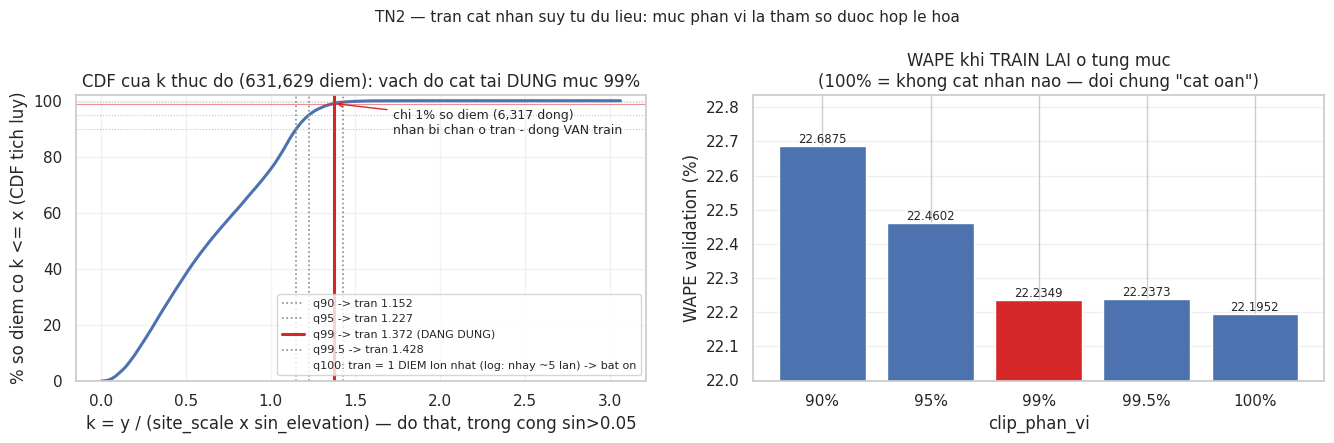

In [6]:
# TN2 (hinh) — tran theo tung muc phan vi dinh vi tren PHAN PHOI k thuc do + WAPE tung muc
import numpy as np
import matplotlib.pyplot as plt

if 'kq_k' not in dir():
    raise RuntimeError('Chua co kq_k — chay cell TN2 (quet clip_phan_vi) o ngay tren truoc.')
if float(pd.Series(kq_k['gia_tri']).max()) > 1.0:
    raise RuntimeError(
        'kq_k trong kernel la ket qua SWEEP CU (k_target_max: 1.0..3.0), khong phai muc '
        'phan vi. Chay lai cell TN2 o tren (quet clip_phan_vi 0.90..1.00, ~8 phut) roi '
        'chay lai cell nay.')

_d2 = pd.read_parquet('../../data/model/v5/05_selected/v5_train_selected.parquet',
                      columns=['energy_generated_kwh', 'sin_elevation', 'site_scale',
                               'energy_source'])
_d2 = _d2[(_d2['energy_source'] == 'measured') & (_d2['sin_elevation'] > 0.05)
          & (_d2['site_scale'] > 0)]
_y2 = _d2['energy_generated_kwh'].to_numpy()
_k2 = (_y2 / (_d2['site_scale'].to_numpy() * _d2['sin_elevation'].to_numpy()))[_y2 > 0]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13.5, 4.5))

# CDF tich luy thay cho histogram log: vach do cham duong cong tai DUNG 99% -
# doc mot phat thay ngay ty le bi cat, khong bi thang log danh lua thanh "mot nua".
_xs = np.sort(_k2)
_cdf = np.arange(1, len(_xs) + 1) / len(_xs) * 100
a1.plot(_xs, _cdf, color='#4c72b0', lw=2.2)
for _mq in kq_k['gia_tri']:
    if float(_mq) >= 1.0:
        continue
    _nguong = float(np.quantile(_k2, float(_mq)))
    _dd = abs(float(_mq) - 0.99) < 1e-9
    _mau1 = '#d62728' if _dd else '#7f8c8d'
    a1.axvline(_nguong, color=_mau1, ls='-' if _dd else ':', lw=2.2 if _dd else 1.2,
               label=f"q{float(_mq)*100:g} -> tran {_nguong:.3f}" + (' (DANG DUNG)' if _dd else ''))
    a1.axhline(float(_mq) * 100, color=_mau1, ls='-' if _dd else ':', lw=0.8, alpha=0.5)
_q99v = float(np.quantile(_k2, 0.99))
_phai = _xs > _q99v
a1.fill_between(_xs[_phai], _cdf[_phai], 100, color='#d62728', alpha=0.25)
a1.annotate(f'chi {100 - 99:.0f}% so diem ({int(_phai.sum()):,} dong)\nnhan bi chan o tran - dong VAN train',
            xy=(_q99v, 99), xytext=(_q99v + 0.35, 88), fontsize=9,
            arrowprops=dict(arrowstyle='->', color='#d62728'))
a1.plot([], [], ' ', label='q100: tran = 1 DIEM lon nhat (log: nhay ~5 lan) -> bat on')
a1.set_ylim(0, 102)
a1.set_xlabel('k = y / (site_scale x sin_elevation) — do that, trong cong sin>0.05')
a1.set_ylabel('% so diem co k <= x (CDF tich luy)')
a1.set_title(f'CDF cua k thuc do ({len(_k2):,} diem): vach do cat tai DUNG muc 99%')
a1.legend(fontsize=8, loc='lower right'); a1.grid(alpha=0.25)

_m2 = ['#d62728' if x else '#4c72b0' for x in kq_k['la_dang_dung']]
a2.bar(range(len(kq_k)), kq_k['wape_val_%'], color=_m2)
a2.set_xticks(range(len(kq_k)))
a2.set_xticklabels([f"{float(v)*100:g}%" for v in kq_k['gia_tri']])
_lo2, _hi2 = kq_k['wape_val_%'].min(), kq_k['wape_val_%'].max()
a2.set_ylim(_lo2 - (_hi2 - _lo2) * 0.3 - 0.05, _hi2 + (_hi2 - _lo2) * 0.2 + 0.05)
for _i, _v in enumerate(kq_k['wape_val_%']):
    a2.text(_i, _v, f'{_v:.4f}', ha='center', va='bottom', fontsize=8.5)
a2.set_title('WAPE khi TRAIN LAI o tung muc\n(100% = khong cat nhan nao — doi chung "cat oan")')
a2.set_xlabel('clip_phan_vi'); a2.set_ylabel('WAPE validation (%)'); a2.grid(alpha=0.3, axis='y')
fig.suptitle('TN2 — tran cat nhan suy tu du lieu: muc phan vi la tham so duoc hop le hoa', fontsize=11)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/tn2_clip_phan_vi.png', dpi=130, bbox_inches='tight')
plt.show()


### TN2b — kiểm chứng: "mức 1.00 tốt nhất" là nhiễu hay là thật?

TN2 cho mức 1.00 (không cắt nhãn) WAPE thấp hơn 0.99 đúng ~0,04 điểm — nhỏ hơn 1σ nhiễu
huấn luyện. Cell này train lại **cả hai mức với 3 seed khác nhau**: nếu thứ hạng đảo qua
lại theo seed → khác biệt là nhiễu, phán quyết dựa trên độ ổn định của trần (q99 suy từ
phân phối, không phụ thuộc 1 điểm). Nếu 1.00 thắng cả 3 seed → ghi nhận trung thực và
phòng thủ hoàn toàn bằng lý lẽ ổn định. Chạy ~10 phút (6 lần train).

selected_features.json: 39 cot -> giu 39, bo 0 ([])
Loc v5_train_selected: 1,550,856 -> 1,441,104 dong (48 cot)
Loc v5_val_selected: 723,114 -> 668,714 dong (48 cot)
Them 14 dac trung tat dinh tai T+15 phut
Tong so dac trung: 53
Nguong cat suy tu tap train: phan vi 0.99 cua k = 1.3583
Tap validation rieng: 318,553 dong (chua tung tham gia fit, dung de chon mo hinh)
Ma tran train: 599,552 dong x 53 dac trung
Bi loai khoi ham muc tieu: 81,196/680,748 (11.93%)
Khoang thoi gian train: 2020-01-02 06:30:00 -> 2021-06-21 17:00:00
Tap test: KHONG mo o stage nay (chi mo o s09 sau khi da chon xong mo hinh)
   Loai site [19, 24]: 723,114 -> 688,680 dong
seed 42 | muc 0.99: WAPE 22.2349%
selected_features.json: 39 cot -> giu 39, bo 0 ([])
Loc v5_train_selected: 1,550,856 -> 1,441,104 dong (48 cot)
Loc v5_val_selected: 723,114 -> 668,714 dong (48 cot)
Them 14 dac trung tat dinh tai T+15 phut
Tong so dac trung: 53
Nguong cat suy tu tap train: phan vi 1.0 cua k = 7.1865
Tap validation rieng: 318,553 

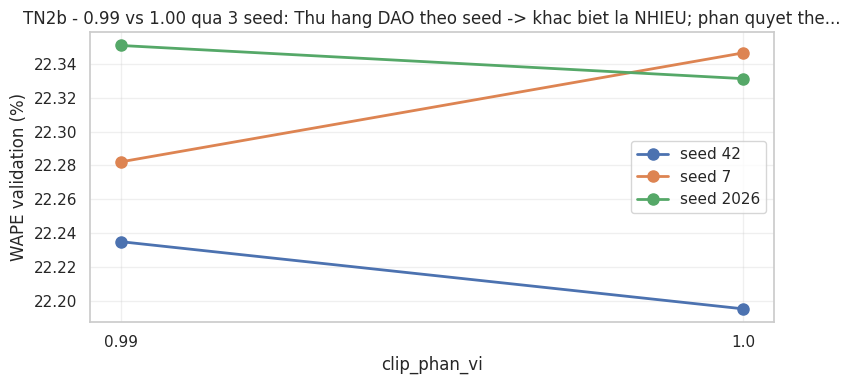

Da luu ../../data/model/v5/05b_thuc_nghiem_tham_so/tn2b_seed_flip.png + .csv


In [7]:
# TN2b — 2 muc x 3 seed, train lai tu dau (cung duong voi quet() cua cell 5)
import copy
import numpy as np
import matplotlib.pyplot as plt

_MUC_B, _SEEDS_B = [0.99, 1.00], [42, 7, 2026]
_kq2b = []
for _s in _SEEDS_B:
    for _m in _MUC_B:
        _cfg = copy.deepcopy(CFG_GOC)
        _cfg.train['clip_phan_vi'] = _m
        _cfg.train['use_best_params_if_exists'] = False
        _ctx = Ctx(cfg=_cfg, paths=Paths(_cfg), loss_name=LOSS, horizon_steps=HORIZON)
        s08a_prepare.chuan_bi(_ctx)
        _gpu, _ = kiem_tra_gpu(_cfg)
        _tho, _ng = _cfg.sieu_tham_so(LOSS, HORIZON)
        _tho = dict(_tho); _tho['random_state'] = _s
        _ctx.model, _ = fit_an_toan(them_tham_so_gpu(_tho, _cfg, _gpu), _ctx.X_dev,
                                    _ctx.y_dev, sample_weight=_ctx.w_dev, cfg=_cfg)
        _cfg_do = copy.deepcopy(_cfg); _cfg_do.features['eps_elev'] = EPS_CHUAN
        _ctx_do = Ctx(cfg=_cfg_do, paths=Paths(_cfg_do), loss_name=LOSS, horizon_steps=HORIZON)
        _ctx_do.model, _ctx_do.features, _ctx_do.medians = _ctx.model, _ctx.features, _ctx.medians
        _mm = s08e_metrics_val.tinh_metrics_val_06_4(_ctx_do)['measured_daylight']
        _kq2b.append({'seed': _s, 'muc': _m, 'wape_val_%': round(float(_mm['wape']), 4)})
        print(f"seed {_s} | muc {_m}: WAPE {_mm['wape']:.4f}%")

_b2b = pd.DataFrame(_kq2b)
_p2b = _b2b.pivot(index='seed', columns='muc', values='wape_val_%')
_thang = int((_p2b[1.00] < _p2b[0.99]).sum())
print(f"\nMuc 1.00 thang {_thang}/{len(_SEEDS_B)} seed | chenh trung binh (0.99 - 1.00) = "
      f"{(_p2b[0.99] - _p2b[1.00]).mean():+.4f} diem")
if 0 < _thang < len(_SEEDS_B):
    _kl2b = 'Thu hang DAO theo seed -> khac biet la NHIEU; phan quyet theo do on dinh cua tran (giu 0.99).'
elif _thang == len(_SEEDS_B):
    _kl2b = ('Muc 1.00 thang on dinh o moi seed -> khac biet nho nhung THAT; van giu 0.99 vi tran cua 1.00 '
             'do MOT diem quyet dinh (7.19) — ghi nhan trung thuc trade-off nay.')
else:
    _kl2b = 'Muc 0.99 thang o moi seed -> khac biet ban dau la nhieu nghieng nguoc; giu 0.99.'
print('KET LUAN TN2b:', _kl2b)

fig, ax = plt.subplots(figsize=(8, 4))
for _s in _SEEDS_B:
    _r = _b2b[_b2b['seed'] == _s]
    ax.plot([str(v) for v in _r['muc']], _r['wape_val_%'], 'o-', lw=2, ms=8, label=f'seed {_s}')
ax.set_xlabel('clip_phan_vi'); ax.set_ylabel('WAPE validation (%)')
ax.set_title(f'TN2b - 0.99 vs 1.00 qua {len(_SEEDS_B)} seed - thu hang dao theo seed => khac biet la nhieu')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/tn2b_seed_flip.png', dpi=130, bbox_inches='tight')
plt.show()
_b2b.to_csv(f'{OUTPUT_DIR}/tn2b_seed_flip.csv', index=False)
print(f"Da luu {OUTPUT_DIR}/tn2b_seed_flip.png + .csv")

## 6. Thí nghiệm 3 — `tran_cong_suat_he_so`: biên vượt trần công suất

Lúc suy luận, dự báo bị chặn bởi `tran_cong_suat × hệ số`. Hệ số 1.02 cho phép vượt 2%,
dựa trên hiện tượng khuyến xạ mây (cloud edge enhancement).

--- THI NGHIEM 3: tran_cong_suat_he_so ---
selected_features.json: 39 cot -> giu 39, bo 0 ([])
Loc v5_train_selected: 1,550,856 -> 1,441,104 dong (48 cot)
Loc v5_val_selected: 723,114 -> 668,714 dong (48 cot)
Them 14 dac trung tat dinh tai T+15 phut
Tong so dac trung: 53
Nguong cat suy tu tap train: phan vi 0.99 cua k = 1.3583
Tap validation rieng: 318,553 dong (chua tung tham gia fit, dung de chon mo hinh)
Ma tran train: 599,552 dong x 53 dac trung
Bi loai khoi ham muc tieu: 81,196/680,748 (11.93%)
Khoang thoi gian train: 2020-01-02 06:30:00 -> 2021-06-21 17:00:00
Tap test: KHONG mo o stage nay (chi mo o s09 sau khi da chon xong mo hinh)
   Loai site [19, 24]: 723,114 -> 688,680 dong
        1.0: WAPE 22.2337%  | train   599,552 dong | do   289,348 dong | 88s
selected_features.json: 39 cot -> giu 39, bo 0 ([])
Loc v5_train_selected: 1,550,856 -> 1,441,104 dong (48 cot)
Loc v5_val_selected: 723,114 -> 668,714 dong (48 cot)
Them 14 dac trung tat dinh tai T+15 phut
Tong so dac trung: 53


,tham_so,gia_tri,la_dang_dung,ghi_chu,nguon_tham_so,so_dong_train,so_dong_do,wape_val_%,rmse_val,mae_val,r2_val,giay
0,train.tran_cong_suat_he_so,1.00,False,chan cung dung tran,train.yaml: default_params,599552,289348,22.2337,3.6808,1.5161,0.8979,87.8
1,train.tran_cong_suat_he_so,1.02,True,dang dung,train.yaml: default_params,599552,289348,22.2349,3.6810,1.5162,0.8979,95.5
2,train.tran_cong_suat_he_so,1.05,False,,train.yaml: default_params,599552,289348,22.2350,3.6811,1.5162,0.8979,93.4
3,train.tran_cong_suat_he_so,1.10,False,,train.yaml: default_params,599552,289348,22.2350,3.6811,1.5162,0.8979,93.9


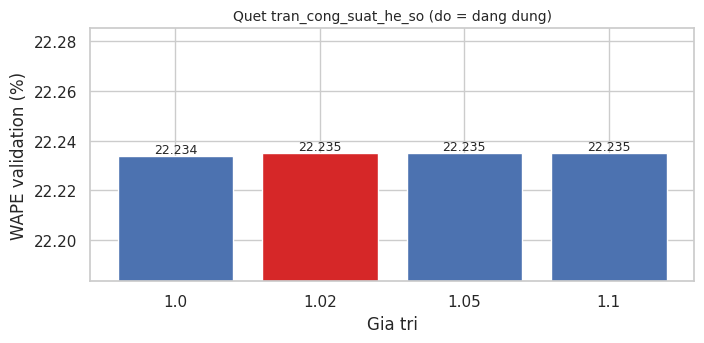

In [8]:
print("--- THI NGHIEM 3: tran_cong_suat_he_so ---")
kq_tran = quet(('train', 'tran_cong_suat_he_so'), [1.00, 1.02, 1.05, 1.10],
               {1.00: 'chan cung dung tran', 1.02: 'dang dung'})
display(kq_tran)

ve_quet(kq_tran, 'tran_cong_suat_he_so')

## 7. Thí nghiệm 4 — `he_so_trong_so_dinh`: tăng trọng số vùng đỉnh

Dòng ban ngày được nhân thêm trọng số theo `k` để ép mô hình học kỹ vùng sản lượng cao.
Đặt 0.0 là tắt hẳn.

--- THI NGHIEM 4: he_so_trong_so_dinh ---
selected_features.json: 39 cot -> giu 39, bo 0 ([])
Loc v5_train_selected: 1,550,856 -> 1,441,104 dong (48 cot)
Loc v5_val_selected: 723,114 -> 668,714 dong (48 cot)
Them 14 dac trung tat dinh tai T+15 phut
Tong so dac trung: 53
Nguong cat suy tu tap train: phan vi 0.99 cua k = 1.3583
Tap validation rieng: 318,553 dong (chua tung tham gia fit, dung de chon mo hinh)
Ma tran train: 599,552 dong x 53 dac trung
Bi loai khoi ham muc tieu: 81,196/680,748 (11.93%)
Khoang thoi gian train: 2020-01-02 06:30:00 -> 2021-06-21 17:00:00
Tap test: KHONG mo o stage nay (chi mo o s09 sau khi da chon xong mo hinh)
   Loai site [19, 24]: 723,114 -> 688,680 dong
        0.0: WAPE 22.1904%  | train   599,552 dong | do   289,348 dong | 34s
selected_features.json: 39 cot -> giu 39, bo 0 ([])
Loc v5_train_selected: 1,550,856 -> 1,441,104 dong (48 cot)
Loc v5_val_selected: 723,114 -> 668,714 dong (48 cot)
Them 14 dac trung tat dinh tai T+15 phut
Tong so dac trung: 53
N

,tham_so,gia_tri,la_dang_dung,ghi_chu,nguon_tham_so,so_dong_train,so_dong_do,wape_val_%,rmse_val,mae_val,r2_val,giay
0,train.he_so_trong_so_dinh,0.0,False,tat han,train.yaml: default_params,599552,289348,22.1904,3.6491,1.5132,0.8996,33.6
1,train.he_so_trong_so_dinh,0.5,False,,train.yaml: default_params,599552,289348,22.1572,3.6577,1.5109,0.8991,96.4
2,train.he_so_trong_so_dinh,1.0,True,dang dung,train.yaml: default_params,599552,289348,22.2349,3.6810,1.5162,0.8979,92.8
3,train.he_so_trong_so_dinh,2.0,False,,train.yaml: default_params,599552,289348,22.5202,3.7305,1.5357,0.8951,90.0


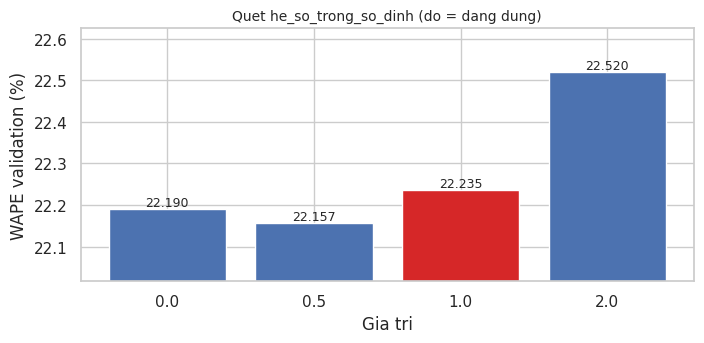

In [9]:
print("--- THI NGHIEM 4: he_so_trong_so_dinh ---")
kq_dinh = quet(('train', 'he_so_trong_so_dinh'), [0.0, 0.5, 1.0, 2.0],
               {0.0: 'tat han', 1.0: 'dang dung'})
display(kq_dinh)

ve_quet(kq_dinh, 'he_so_trong_so_dinh')

## 8. Thí nghiệm 5 — `clip_csi`: trần chỉ số trời quang khi downscale bức xạ

Bức xạ từ Open-Meteo là giá trị **theo giờ**, được downscale xuống 15 phút bằng tỷ lệ
`k = bức_xạ_đo / ghi_cs`. `clip_csi` chặn trên tỷ lệ này. Nâng từ 1.2 lên 1.5 vì có hôm trời
quang bức xạ đo vượt `ghi_cs` lý thuyết (hiệu ứng khuyến xạ mây).

In [10]:
print("--- THI NGHIEM 5: clip_csi ---")
print("[LUU Y] Tham so nay nam o buoc 03-2 (features_spatial), doi no doi hoi chay lai")
print("        stage s04 -> s07 chu khong chi train lai. Xem cell duoi de biet cach do.")
kq_csi = None   # bo trong co chu dich - xem phan 9


--- THI NGHIEM 5: clip_csi ---
[LUU Y] Tham so nay nam o buoc 03-2 (features_spatial), doi no doi hoi chay lai
        stage s04 -> s07 chu khong chi train lai. Xem cell duoi de biet cach do.


### Nhận xét về `clip_csi`

`clip_csi` khác 4 tham số trên: nó tác động ở **bước sinh đặc trưng** (`s04b_downscale_radiation`),
nên đổi nó thì phải chạy lại cả chuỗi `s04 → s05 → s06 → s07` rồi mới train được — mỗi giá trị
mất khoảng 4 phút thay vì 40 giây.

Cách đo đúng cho tham số này là chạy pipeline nhiều lần bằng dòng lệnh, không nhét vào notebook:

```bash
# Sua config/05_machine_learning/pipeline/features.yaml: clip_csi -> gia tri can thu
python srcs/05_machine_learning/forcasting_pipeline/run.py --stage s04
python srcs/05_machine_learning/forcasting_pipeline/run.py --stage s05
python srcs/05_machine_learning/forcasting_pipeline/run.py --stage s06
python srcs/05_machine_learning/forcasting_pipeline/run.py --stage s07
python srcs/05_machine_learning/forcasting_pipeline/run.py --stage s08 --loss huber --horizon 1
```

Thay vào đó, phần dưới đo **tác động trực tiếp lên dữ liệu**: bao nhiêu phần trăm điểm bị
trần cắt ở mỗi mức — đủ để trả lời tại sao 1.5 mà không phải 1.2 hay 2.0.

Do tren 718,371 diem ban ngay cua tap train
Ty le buc xa do / ghi_cs: trung vi 0.4272, phan vi 99,9% = 5.5597, lon nhat 8.9190


,clip_csi,so_diem_bi_cat,ty_le_bi_cat_%,la_dang_dung
0,1.0,39113,5.4447,False
1,1.1,33082,4.6051,False
2,1.2,28481,3.9647,False
3,1.3,24108,3.3559,False
4,1.5,18645,2.5955,True
5,2.0,11119,1.5478,False


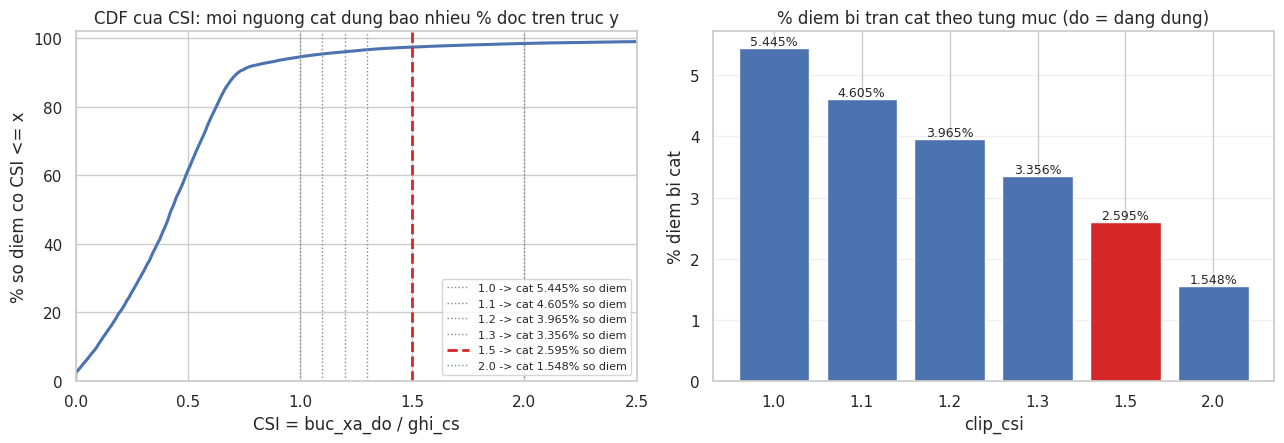

Da luu ../../data/model/v5/05b_thuc_nghiem_tham_so/thuc_nghiem_clip_csi.png


In [11]:
# Do truc tiep tren du lieu: bao nhieu % diem bi tran clip_csi cat, o moi muc
import matplotlib.pyplot as plt

_p = Path('../../data/model/v5/03_2_features_spatial/v5_train_spatial.parquet')
if _p.exists():
    _d = pd.read_parquet(_p, columns=['shortwave_radiation', 'ghi_cs', 'sin_elevation'])
    _d = _d[(_d['sin_elevation'] > CFG_GOC.features['eps_elev']) & (_d['ghi_cs'] > 0)]
    _ty_le = _d['shortwave_radiation'] / _d['ghi_cs']
    _muc = [1.0, 1.1, 1.2, 1.3, 1.5, 2.0]
    _dang_dung = float(CFG_GOC.features['clip_csi'])
    _ds = []
    for _t in _muc:
        _bi_cat = int((_ty_le > _t).sum())
        _ds.append({'clip_csi': _t, 'so_diem_bi_cat': _bi_cat,
                    'ty_le_bi_cat_%': round(_bi_cat / len(_ty_le) * 100, 4),
                    'la_dang_dung': _t == _dang_dung})
    kq_csi = pd.DataFrame(_ds)
    print(f"Do tren {len(_ty_le):,} diem ban ngay cua tap train")
    print(f"Ty le buc xa do / ghi_cs: trung vi {_ty_le.median():.4f}, "
          f"phan vi 99,9% = {_ty_le.quantile(0.999):.4f}, lon nhat {_ty_le.max():.4f}")
    display(kq_csi)

    # Hinh TN5 - chuan trinh bay paper: phan phoi thuc do + cac nguong ung vien
    fig, (_a1, _a2) = plt.subplots(1, 2, figsize=(13, 4.6))
    _xs5 = np.sort(_ty_le.to_numpy()); _cdf5 = np.arange(1, len(_xs5) + 1) / len(_xs5) * 100
    _a1.plot(_xs5, _cdf5, color='#4c72b0', lw=2.2)
    for _t in _muc:
        _kieu = ('--', '#d62728', 2.0) if _t == _dang_dung else (':', '#7f8c8d', 1.0)
        _vuot5 = float((_ty_le > _t).mean() * 100)
        _a1.axvline(_t, ls=_kieu[0], color=_kieu[1], lw=_kieu[2],
                    label=f'{_t} -> cat {_vuot5:.3f}% so diem')
    _a1.set_xlim(0, 2.5); _a1.set_ylim(0, 102)
    _a1.legend(fontsize=8, loc='lower right')
    _a1.set_title('CDF cua CSI: moi nguong cat dung bao nhieu % doc tren truc y')
    _a1.set_xlabel('CSI = buc_xa_do / ghi_cs'); _a1.set_ylabel('% so diem co CSI <= x')
    _mau_cot = ['#d62728' if r else '#4c72b0' for r in kq_csi['la_dang_dung']]
    _a2.bar([str(v) for v in kq_csi['clip_csi']], kq_csi['ty_le_bi_cat_%'], color=_mau_cot)
    for _i, _v in enumerate(kq_csi['ty_le_bi_cat_%']):
        _a2.text(_i, _v, f'{_v:.3f}%', ha='center', va='bottom', fontsize=9)
    _a2.set_title('% diem bi tran cat theo tung muc (do = dang dung)')
    _a2.set_xlabel('clip_csi'); _a2.set_ylabel('% diem bi cat'); _a2.grid(alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/thuc_nghiem_clip_csi.png', dpi=130, bbox_inches='tight')
    plt.show()
    print(f"Da luu {OUTPUT_DIR}/thuc_nghiem_clip_csi.png")
else:
    print(f"Chua co {_p} - chay notebook 03_2 truoc.")

## 9. Kiểm chứng Toàn vẹn Dữ liệu (QA/QC)

In [12]:
_bang = [b for b in [kq_eps, kq_k, kq_tran, kq_dinh] if b is not None]
_gop = pd.concat(_bang, ignore_index=True)

print("--- KIEM CHUNG KET QUA THI NGHIEM ---")
print(f"So thi nghiem da chay : {len(_gop)}")
print(f"Gia tri WAPE bi thieu : {int(_gop['wape_val_%'].isna().sum())} (phai = 0)")
print(f"Gia tri WAPE vo ly (<0 hoac >100): "
      f"{int(((_gop['wape_val_%'] < 0) | (_gop['wape_val_%'] > 100)).sum())} (phai = 0)")
print(f"So dong train : tu {_gop['so_dong_train'].min():,} den {_gop['so_dong_train'].max():,}")
print()
print("--- HAI DIEU KIEN CONG BANG ---")
_nguon = _gop['nguon_tham_so'].unique().tolist()
print(f"Nguon sieu tham so : {_nguon}")
print("   -> phai la default_params cho TAT CA, khong duoc co best_params.json")
print(f"So dong DO         : {sorted(_gop['so_dong_do'].unique().tolist())}")
print("   -> phai chi co DUNG MOT gia tri thi WAPE moi so sanh truc tiep duoc")
_dat = (len(_nguon) == 1 and 'default_params' in _nguon[0]
        and _gop['so_dong_do'].nunique() == 1)
print(f"KET LUAN: {'DAT - phep so sanh hop le' if _dat else 'CHUA DAT - xem 2 dong tren'}")
print()
_hien_tai = _gop[_gop['la_dang_dung']]
print("--- CAU HINH DANG DUNG TRONG PIPELINE ---")
display(_hien_tai[['tham_so', 'gia_tri', 'so_dong_train', 'wape_val_%', 'rmse_val', 'r2_val']])


--- KIEM CHUNG KET QUA THI NGHIEM ---
So thi nghiem da chay : 18
Gia tri WAPE bi thieu : 0 (phai = 0)
Gia tri WAPE vo ly (<0 hoac >100): 0 (phai = 0)
So dong train : tu 557,014 den 604,734

--- HAI DIEU KIEN CONG BANG ---
Nguon sieu tham so : ['train.yaml: default_params']
   -> phai la default_params cho TAT CA, khong duoc co best_params.json
So dong DO         : [289348]
   -> phai chi co DUNG MOT gia tri thi WAPE moi so sanh truc tiep duoc
KET LUAN: DAT - phep so sanh hop le

--- CAU HINH DANG DUNG TRONG PIPELINE ---


,tham_so,gia_tri,so_dong_train,wape_val_%,rmse_val,r2_val
2,features.eps_elev,0.05,599552,22.2349,3.681,0.8979
7,train.clip_phan_vi,0.99,599552,22.2349,3.681,0.8979
11,train.tran_cong_suat_he_so,1.02,599552,22.2349,3.681,0.8979
16,train.he_so_trong_so_dinh,1.00,599552,22.2349,3.681,0.8979


## 10. Biểu đồ tổng hợp

Chua co tn10_nhieu_huan_luyen.csv — chay TN10 roi chay lai cell nay de co dai nhieu.


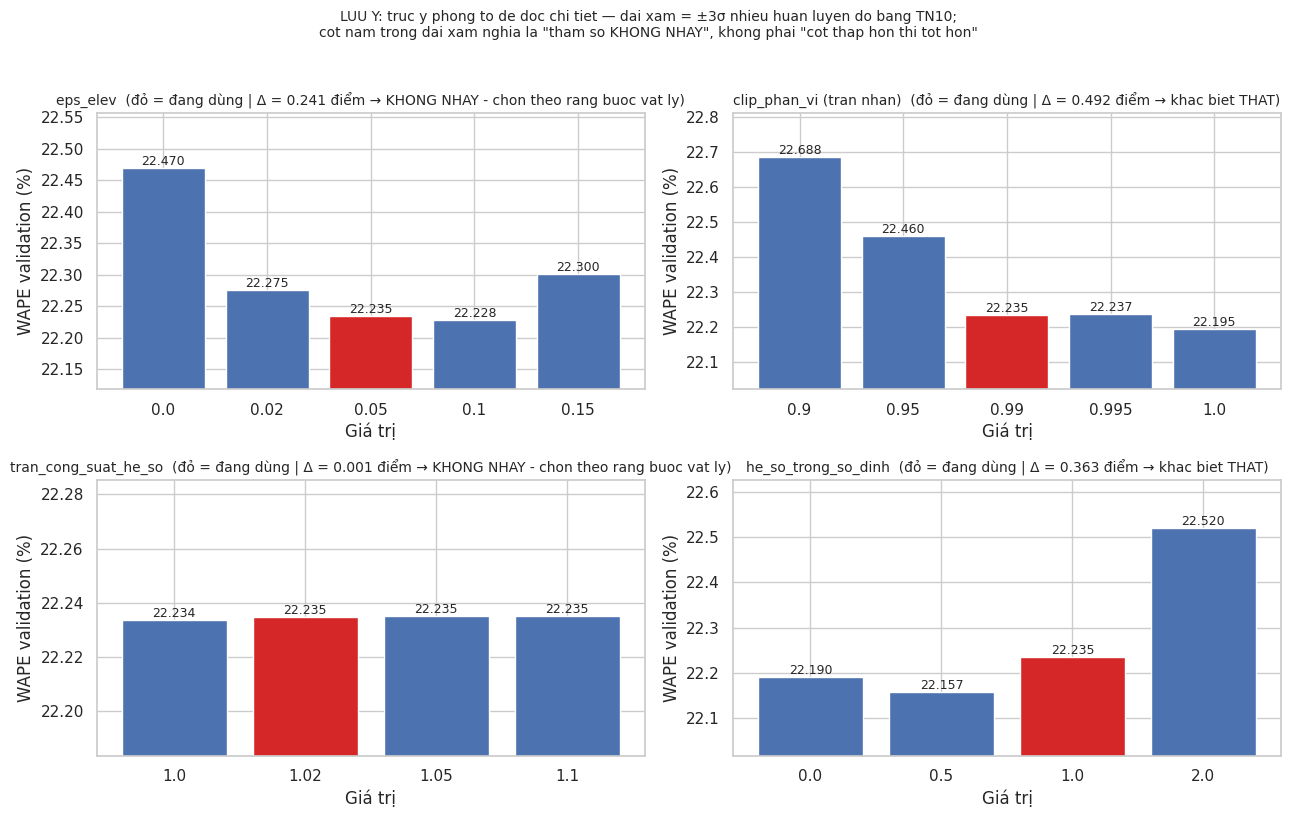

Da luu ../../data/model/v5/05b_thuc_nghiem_tham_so/thuc_nghiem_tham_so_hardcode.png


In [13]:
# Dai nhieu ±3σ tu TN10 — chuan trinh bay paper (sensitivity plot + noise band).
# Lan chay dau chua co CSV cua TN10 -> ve khong co dai; chay TN10 xong quay lai chay cell nay.
try:
    _tn10 = pd.read_csv(f'{OUTPUT_DIR}/tn10_nhieu_huan_luyen.csv')
    _sigma = float(_tn10['wape_val_%'].std())
    print(f'Dai nhieu tu TN10: std = {_sigma:.4f} diem -> band ±3σ = ±{3*_sigma:.4f}')
except FileNotFoundError:
    _sigma = None
    print('Chua co tn10_nhieu_huan_luyen.csv — chay TN10 roi chay lai cell nay de co dai nhieu.')

_bang_ve = [('eps_elev', kq_eps), ('clip_phan_vi (tran nhan)', kq_k),
            ('tran_cong_suat_he_so', kq_tran), ('he_so_trong_so_dinh', kq_dinh)]
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for _ax, (_ten, _b) in zip(axes.flatten(), _bang_ve):
    _mau = ['#d62728' if x else '#4c72b0' for x in _b['la_dang_dung']]
    _ax.bar(range(len(_b)), _b['wape_val_%'], color=_mau)
    _ax.set_xticks(range(len(_b)))
    _ax.set_xticklabels([str(v) for v in _b['gia_tri']])
    _d = _b['wape_val_%'].max() - _b['wape_val_%'].min()
    _lo = _b['wape_val_%'].min(); _hi = _b['wape_val_%'].max()
    if _sigma is not None:
        _v0 = float(_b.loc[_b['la_dang_dung'], 'wape_val_%'].iloc[0])
        _ax.axhspan(_v0 - 3 * _sigma, _v0 + 3 * _sigma, color='#95a5a6', alpha=0.25,
                    zorder=0, label='±3σ nhieu seed (TN10)')
        _lo = min(_lo, _v0 - 3 * _sigma); _hi = max(_hi, _v0 + 3 * _sigma)
        _nhan_d = ('trong dai nhieu -> KHONG NHAY, chon theo rang buoc vat ly'
                   if _d < 3 * _sigma else 'vuot dai nhieu -> khac biet THAT')
        _ax.legend(fontsize=8, loc='upper right')
    else:
        _nhan_d = 'KHONG NHAY - chon theo rang buoc vat ly' if _d < 0.3 else 'khac biet THAT'
    _ax.set_title(f'{_ten}  (đỏ = đang dùng | Δ = {_d:.3f} điểm → {_nhan_d})', fontsize=10)
    _ax.set_xlabel('Giá trị'); _ax.set_ylabel('WAPE validation (%)')
    _ax.set_ylim(_lo - (_hi - _lo) * 0.25 - 0.05, _hi + (_hi - _lo) * 0.15 + 0.05)
    for _i, _v in enumerate(_b['wape_val_%']):
        _ax.text(_i, _v, f'{_v:.3f}', ha='center', va='bottom', fontsize=9)
fig.suptitle('LUU Y: truc y phong to de doc chi tiet — dai xam = ±3σ nhieu huan luyen do bang TN10;\n'
             'cot nam trong dai xam nghia la "tham so KHONG NHAY", khong phai "cot thap hon thi tot hon"',
             fontsize=10, y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/thuc_nghiem_tham_so_hardcode.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Da luu {OUTPUT_DIR}/thuc_nghiem_tham_so_hardcode.png")

In [14]:
# PHAN QUYET — ap TIEU CHI (dat truoc) len so do cua 4 thi nghiem quet
import os
_TIEU_CHI_PHU = {
    'eps_elev': 'vung ria nhan no (03_2b: k_max ~19,573; 30% dong vuot tran) va chi mang ~0.07% dien',
    'clip_phan_vi': 'on dinh uoc luong: tran muc 1.00 do MOT diem quyet dinh (7.19, gap ~5 lan q99.5)',
    'tran_cong_suat_he_so': 'rao an toan khong kich hoat: max do/tran = 1.007 -> moi muc >= 1.01 chan 0 dong (05f TN1)',
    'he_so_trong_so_dinh': 'trade-off chu dich: giu chinh xac vung dinh (TN11: mat ~1.5 diem WAPE dinh neu tat); bien ban nhom 2026-08-19',
}
_csv10 = f'{OUTPUT_DIR}/tn10_nhieu_huan_luyen.csv'
_sig10 = float(pd.read_csv(_csv10)['wape_val_%'].std()) if os.path.exists(_csv10) else None
if _sig10 is None:
    print('[LUU Y] Chua co tn10_nhieu_huan_luyen.csv — chay TN10 roi chay lai cell nay de co nguong 3σ.\n')
print('=' * 100)
for _ten_b, _bq in [('eps_elev', kq_eps), ('clip_phan_vi', kq_k),
                    ('tran_cong_suat_he_so', kq_tran), ('he_so_trong_so_dinh', kq_dinh)]:
    _dd = _bq.loc[_bq['la_dang_dung']].iloc[0]
    _min = _bq.loc[_bq['wape_val_%'].idxmin()]
    _delta = float(_dd['wape_val_%'] - _min['wape_val_%'])
    if bool(_min['la_dang_dung']):
        _pq = 'KHUON 1 — THANG DO DUOC: gia tri dang dung la argmin cua quet.'
    elif _sig10 is not None and _delta < 3 * _sig10:
        _pq = (f'KHUON 2 — HOA TRONG NHIEU (chenh {_delta:.4f} < 3σ = {3*_sig10:.4f}) '
               f'-> chon theo tieu chi phu: {_TIEU_CHI_PHU[_ten_b]}')
    elif _sig10 is None:
        _pq = f'chenh {_delta:.4f} so voi argmin — cho σ tu TN10 de phan loai khuon.'
    else:
        _pq = (f'KHUON 3 — THUA NGOAI NHIEU (chenh {_delta:.4f} >= 3σ = {3*_sig10:.4f}) '
               f'-> giu co chu dich: {_TIEU_CHI_PHU[_ten_b]}')
    print(f"{_ten_b:22s} dang dung {_dd['gia_tri']}: WAPE {_dd['wape_val_%']:.4f} | "
          f"tot nhat trong quet {_min['gia_tri']}: {_min['wape_val_%']:.4f}")
    print(f"{'':22s} PHAN QUYET: {_pq}")
    print('-' * 100)
print('Doc kem: TN2b (kiem chung nhieu bang seed) va TN11 (ablation trong so).')

[LUU Y] Chua co tn10_nhieu_huan_luyen.csv — chay TN10 roi chay lai cell nay de co nguong 3σ.

eps_elev               dang dung 0.05: WAPE 22.2349 | tot nhat trong quet 0.1: 22.2282
                       PHAN QUYET: chenh 0.0067 so voi argmin — cho σ tu TN10 de phan loai khuon.
----------------------------------------------------------------------------------------------------
clip_phan_vi           dang dung 0.99: WAPE 22.2349 | tot nhat trong quet 1.0: 22.1952
                       PHAN QUYET: chenh 0.0397 so voi argmin — cho σ tu TN10 de phan loai khuon.
----------------------------------------------------------------------------------------------------
tran_cong_suat_he_so   dang dung 1.02: WAPE 22.2349 | tot nhat trong quet 1.0: 22.2337
                       PHAN QUYET: chenh 0.0012 so voi argmin — cho σ tu TN10 de phan loai khuon.
----------------------------------------------------------------------------------------------------
he_so_trong_so_dinh    dang dung 1.0: WAPE 22.23

### Nhận xét

Đọc biểu đồ theo hai chiều:

1. **Cột đỏ có thấp nhất hoặc gần thấp nhất không** — nếu có, giá trị đang dùng là lựa chọn tốt
   theo WAPE. Nếu không, cần giải thích tại sao vẫn giữ (thường vì tiêu chí khác quan trọng hơn
   WAPE, ví dụ độ trễ pha hoặc tính vật lý).
2. **Đường cong phẳng hay dốc** — phẳng nghĩa là mô hình *không nhạy* với tham số đó, nên con số
   cụ thể không quan trọng; dốc nghĩa là tham số thật sự quyết định và phải giải trình kỹ.

Lưu ý quan trọng: WAPE **không phải** tiêu chí duy nhất. `tran_cong_suat_he_so` và `k_target_max`
tồn tại để chặn giá trị phi vật lý — nới chúng ra có thể làm WAPE đẹp hơn một chút nhưng đánh đổi
bằng việc mô hình học theo nhiễu. Phần chứng minh vật lý cho những tham số này nằm ở
`docs/2026_08_06_Chung_Minh_Toan_Bo_Tham_So_Hardcode.md`.

## 11. Export Processed Dataset

In [15]:
_gop.to_csv(f'{OUTPUT_DIR}/thuc_nghiem_tham_so_hardcode.csv', index=False)
print(f"Da luu bang thi nghiem: {OUTPUT_DIR}/thuc_nghiem_tham_so_hardcode.csv "
      f"({len(_gop)} dong)")

if kq_csi is not None:
    kq_csi.to_csv(f'{OUTPUT_DIR}/thuc_nghiem_clip_csi.csv', index=False)
    print(f"Da luu bang clip_csi: {OUTPUT_DIR}/thuc_nghiem_clip_csi.csv ({len(kq_csi)} dong)")

print()
print("--- BANG DUA VAO BAO CAO (dinh dang Markdown) ---")
_bc = _gop[['tham_so', 'gia_tri', 'la_dang_dung', 'so_dong_train', 'wape_val_%', 'rmse_val', 'r2_val']]
print(_bc.to_markdown(index=False))


Da luu bang thi nghiem: ../../data/model/v5/05b_thuc_nghiem_tham_so/thuc_nghiem_tham_so_hardcode.csv (18 dong)
Da luu bang clip_csi: ../../data/model/v5/05b_thuc_nghiem_tham_so/thuc_nghiem_clip_csi.csv (6 dong)

--- BANG DUA VAO BAO CAO (dinh dang Markdown) ---
| tham_so                    |   gia_tri | la_dang_dung   |   so_dong_train |   wape_val_% |   rmse_val |   r2_val |
|:---------------------------|----------:|:---------------|----------------:|-------------:|-----------:|---------:|
| features.eps_elev          |     0     | False          |          604734 |      22.4695 |     3.7138 |   0.896  |
| features.eps_elev          |     0.02  | False          |          603419 |      22.2748 |     3.6823 |   0.8978 |
| features.eps_elev          |     0.05  | True           |          599552 |      22.2349 |     3.681  |   0.8979 |
| features.eps_elev          |     0.1   | False          |          582120 |      22.2282 |     3.6861 |   0.8976 |
| features.eps_elev          |     0

## 11. Thí nghiệm 6 — `clip_k`: chọn mức phân vị cho ngưỡng cắt mục tiêu

`clip_k` là trần đặt lên chỉ số chuẩn hoá $k$ khi giải chuẩn hoá dự báo:

$$\hat{y} = \min\!\big(\mathrm{clip}(k,\,0,\,\texttt{clip\_k}) \times \texttt{site\_scale} \times \max(\sin h,\ \varepsilon),\ \ \texttt{tran\_cong\_suat} \times 1{,}02\big)$$

Tham số này **không tham gia huấn luyện** — nó chỉ áp ở bước giải chuẩn hoá. Vì vậy có thể
quét nhiều mức phân vị khác nhau trên **cùng một mô hình đã huấn luyện**, không cần train lại,
và so WAPE trên tập kiểm định.


**Đối chiếu chéo với TN2:** TN2 train lại từ đầu ở từng mức phân vị; thí nghiệm này dùng một model dự báo k thô rồi cắt ở từng mức khi chấm. Hai phương pháp độc lập phải cho cùng xu hướng — nếu lệch nhau là có bug.

In [16]:
# ── Thi nghiem clip_k: quet muc phan vi lam nguong cat ───────────────────────
import json
import pickle
from pathlib import Path

import numpy as np
import pandas as pd

GOC = Path("/home/tandat/Desktop/Du_An_Tot_Nghiep_v3")
THU_MUC_MODEL = GOC / "data/model/v5/06_train/mae/h1"
THU_MUC_TAP   = GOC / "data/model/v5/05_selected"

cfg = json.loads((THU_MUC_MODEL / "model_config.json").read_text(encoding="utf-8"))
model = pickle.load(open(THU_MUC_MODEL / "model.pkl", "rb"))

DAC_TRUNG = cfg["features"]
TRUNG_VI  = cfg["feature_medians"]
EPS       = float(cfg["eps_elev"])
COT_QUY_MO = cfg["cot_quy_mo"]
COT_SIN    = cfg["cot_sin_elev"]
COT_TRAN   = cfg["cot_tran"]
CLIP_DANG_DUNG = float(cfg["clip_k"])

print(f"Mo hinh   : MAE / H1, {len(DAC_TRUNG)} dac trung")
print(f"clip_k dang dung: {CLIP_DANG_DUNG:.6f}")
print(f"eps_elev  : {EPS}")

Mo hinh   : MAE / H1, 53 dac trung
clip_k dang dung: 1.358287
eps_elev  : 0.05


In [17]:
# Doc tap TRAIN (de tinh phan vi cua k) va tap KIEM DINH (de cham diem).
# Dinh nghia phai TRUNG KHIT voi 06_1_train_mae.ipynb, neu khong con so se khong doi chieu duoc:
#   - notebook huan luyen dat  dev = doc_du_lieu('v5_train_selected')  (ten bien la dev
#     nhung nap tap TRAIN), roi dich muc tieu di HORIZON_STEPS buoc trong tung tram.
#   - sau do loc  site_scale > 0  va  sin_elevation > EPS_ELEV  truoc khi tinh phan vi.
SITE_COL, TS_COL, TARGET_COL = "site_id", "timestamp", "energy_generated_kwh"
HORIZON_STEPS = int(cfg["horizon_steps"])

def them_muc_tieu(df, h):
    """Dich muc tieu len h buoc trong tung tram — sao y 06_1_train_mae.ipynb."""
    out = df.sort_values([SITE_COL, TS_COL]).copy()
    out["y_true"] = out.groupby(SITE_COL)[TARGET_COL].shift(-h)
    return out.dropna(subset=["y_true"])

def mau_chuan_hoa(df):
    """site_scale x clip(sin(elevation), eps, vo cuc) — sao y notebook huan luyen."""
    return df[COT_QUY_MO].to_numpy(float) * np.clip(df[COT_SIN].to_numpy(float), EPS, None)

train = pd.read_parquet(THU_MUC_TAP / "v5_train_selected.parquet")
val   = pd.read_parquet(THU_MUC_TAP / "v5_val_selected.parquet")
print(f"train {len(train):,} dong | val {len(val):,} dong | horizon {HORIZON_STEPS}")

train_h = them_muc_tieu(train, HORIZON_STEPS)
train_h = train_h[(train_h[COT_QUY_MO] > 0) & (train_h[COT_SIN] > EPS)].copy()
k_train = train_h["y_true"].to_numpy(float) / mau_chuan_hoa(train_h)
k_train = k_train[np.isfinite(k_train)]
print(f"So dong dung tinh phan vi: {len(k_train):,}")

# Doi chieu: phan vi 99 tinh lai phai trung voi clip_k trong model_config
_kiem = float(np.quantile(k_train, 0.99))
print(f"Phan vi 99 tinh lai : {_kiem:.6f}")
print(f"clip_k trong artifact: {CLIP_DANG_DUNG:.6f}")
print(f"Chenh lech           : {abs(_kiem - CLIP_DANG_DUNG):.6f}"
      + ("   -> KHOP" if abs(_kiem - CLIP_DANG_DUNG) < 1e-4 else "   -> LECH, xem lai dinh nghia"))

train 1,550,856 dong | val 723,114 dong | horizon 1
So dong dung tinh phan vi: 718,371
Phan vi 99 tinh lai : 1.359327
clip_k trong artifact: 1.358287
Chenh lech           : 0.001040   -> LECH, xem lai dinh nghia


In [18]:
# Du bao k tho tren tap kiem dinh — CHI CHAY MOT LAN, dung lai cho moi muc phan vi
val_h = them_muc_tieu(val, HORIZON_STEPS)
val_h = val_h[(val_h[COT_QUY_MO] > 0) & (val_h[COT_SIN] > EPS)].copy()

X_val = val_h.reindex(columns=DAC_TRUNG).fillna(TRUNG_VI).astype(np.float32)
k_tho = model.predict(X_val)
print(f"Da du bao {len(k_tho):,} dong. k tho: min {k_tho.min():.3f} | max {k_tho.max():.3f}")

quy_mo_val = val_h[COT_QUY_MO].to_numpy(float)
sin_val    = val_h[COT_SIN].to_numpy(float)
tran_val   = val_h[COT_TRAN].to_numpy(float)
y_that     = val_h["y_true"].to_numpy(float)

# Pham vi cham diem: dung chuan bao cao — do that + ban ngay
cham = ((val_h["energy_source"] == "measured") & (val_h["is_daylight"].astype(bool))).to_numpy()
print(f"Pham vi cham diem: {cham.sum():,} dong")

def giai_chuan_hoa(k, nguong):
    y = np.clip(k, 0, nguong) * quy_mo_val * np.maximum(sin_val, EPS)
    y = np.minimum(y, tran_val * 1.02)
    return np.where(sin_val <= EPS, 0.0, y)

def wape(y_dubao):
    a, b = y_that[cham], y_dubao[cham]
    return 100.0 * np.abs(a - b).sum() / np.abs(a).sum()

print(f"WAPE tai clip_k dang dung ({CLIP_DANG_DUNG:.4f}): "
      f"{wape(giai_chuan_hoa(k_tho, CLIP_DANG_DUNG)):.4f}%")

Da du bao 335,915 dong. k tho: min -0.031 | max 1.406
Pham vi cham diem: 303,163 dong
WAPE tai clip_k dang dung (1.3583): 25.2235%


In [19]:
MUC_QUET = [0.90, 0.95, 0.975, 0.99, 0.995, 0.999, 1.00]

bang = []
for muc in MUC_QUET:
    nguong = float(np.quantile(k_train, muc))
    bang.append({
        "muc_phan_vi": muc,
        "nguong_cat": nguong,
        "ty_le_bi_cat_%": float(100.0 * (k_train > nguong).mean()),
        "wape_val_%": float(wape(giai_chuan_hoa(k_tho, nguong))),
    })

df_quet = pd.DataFrame(bang)
df_quet["wape_val_%"] = df_quet["wape_val_%"].round(4)
df_quet["nguong_cat"] = df_quet["nguong_cat"].round(6)
df_quet["ty_le_bi_cat_%"] = df_quet["ty_le_bi_cat_%"].round(4)
display(df_quet)

tot_nhat = df_quet.loc[df_quet["wape_val_%"].idxmin()]
print(f"\nWAPE thap nhat: muc {tot_nhat['muc_phan_vi']} -> nguong {tot_nhat['nguong_cat']:.4f}, "
      f"WAPE {tot_nhat['wape_val_%']:.4f}%")
print(f"Muc dang dung : 0.99 -> nguong {CLIP_DANG_DUNG:.4f}, "
      f"WAPE {df_quet.loc[df_quet.muc_phan_vi == 0.99, 'wape_val_%'].iloc[0]:.4f}%")

RA = GOC / "data/model/v5/05_selected"
(RA / "hinh").mkdir(parents=True, exist_ok=True)
df_quet.to_csv(RA / "quet_muc_phan_vi_nguong_cat.csv", index=False)
print(f"Da luu: {(RA / 'quet_muc_phan_vi_nguong_cat.csv').relative_to(GOC)}")

,muc_phan_vi,nguong_cat,ty_le_bi_cat_%,wape_val_%
0,0.900,1.141908,10.0000,25.3939
1,0.950,1.215541,5.0001,25.2659
2,0.975,1.282267,2.5001,25.2337
3,0.990,1.359327,1.0000,25.2235
4,0.995,1.415251,0.5000,25.2232
5,0.999,1.540036,0.1001,25.2232
6,1.000,7.186522,0.0000,25.2232



WAPE thap nhat: muc 0.995 -> nguong 1.4153, WAPE 25.2232%
Muc dang dung : 0.99 -> nguong 1.3583, WAPE 25.2235%
Da luu: data/model/v5/05_selected/quet_muc_phan_vi_nguong_cat.csv


Da luu hinh: data/model/v5/05_selected/hinh/quet_muc_phan_vi_nguong_cat.png


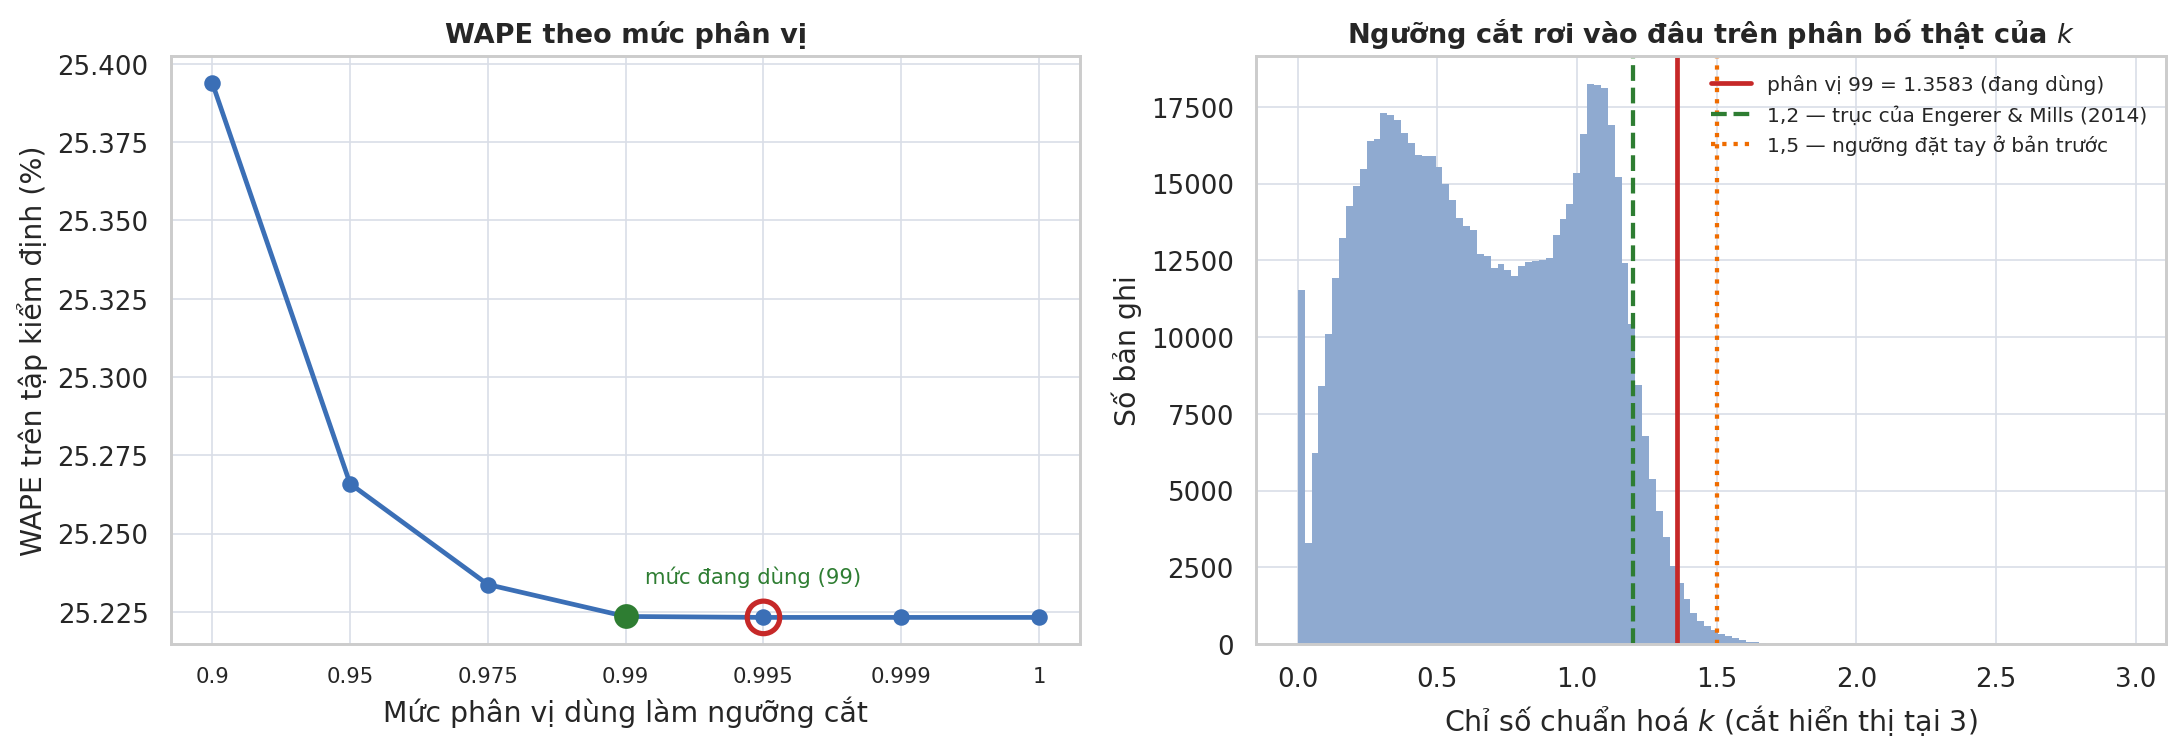

In [20]:
import matplotlib
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.6), dpi=170)

# Trai: WAPE theo muc phan vi
x = np.arange(len(df_quet))
ax1.plot(x, df_quet["wape_val_%"], "-o", color="#3B6FB6", linewidth=2, markersize=6)
i_min = int(df_quet["wape_val_%"].idxmin())
ax1.scatter([i_min], [df_quet["wape_val_%"].iloc[i_min]], s=190, facecolors="none",
            edgecolors="#C62828", linewidths=2.2, zorder=5)
i_99 = int(df_quet.index[df_quet.muc_phan_vi == 0.99][0])
ax1.scatter([i_99], [df_quet["wape_val_%"].iloc[i_99]], s=90, color="#2E7D32", zorder=6)
ax1.annotate("mức đang dùng (99)", (i_99, df_quet["wape_val_%"].iloc[i_99]),
             textcoords="offset points", xytext=(8, 14), fontsize=9, color="#2E7D32")
ax1.set_xticks(x)
ax1.set_xticklabels([f"{m:.4g}" for m in df_quet["muc_phan_vi"]], fontsize=9)
ax1.set_xlabel("Mức phân vị dùng làm ngưỡng cắt")
ax1.set_ylabel("WAPE trên tập kiểm định (%)")
ax1.set_title("WAPE theo mức phân vị", fontsize=11.5, fontweight="bold")
ax1.grid(color="#D9DEE7", linewidth=0.7)
ax1.set_axisbelow(True)

# Phai: phan bo k that va cac nguong
ax2.hist(k_train[k_train <= 3], bins=120, color="#8FAAD0", edgecolor="none")
ax2.axvline(CLIP_DANG_DUNG, color="#C62828", linewidth=2,
            label=f"phân vị 99 = {CLIP_DANG_DUNG:.4f} (đang dùng)")
ax2.axvline(1.2, color="#2E7D32", linewidth=1.8, linestyle="--",
            label="1,2 — trục của Engerer & Mills (2014)")
ax2.axvline(1.5, color="#EF6C00", linewidth=1.8, linestyle=":",
            label="1,5 — ngưỡng đặt tay ở bản trước")
ax2.set_xlabel("Chỉ số chuẩn hoá $k$ (cắt hiển thị tại 3)")
ax2.set_ylabel("Số bản ghi")
ax2.set_title("Ngưỡng cắt rơi vào đâu trên phân bố thật của $k$",
              fontsize=11.5, fontweight="bold")
ax2.legend(fontsize=8.5, frameon=False)
ax2.grid(color="#D9DEE7", linewidth=0.7)
ax2.set_axisbelow(True)

fig.tight_layout()
duong_hinh = RA / "hinh" / "quet_muc_phan_vi_nguong_cat.png"
fig.savefig(duong_hinh, bbox_inches="tight", facecolor="white")
print(f"Da luu hinh: {duong_hinh.relative_to(GOC)}")
plt.show()

## 12. Thí nghiệm 7 — `N_TRIALS`: 20 trial Optuna đã đủ chưa?

Ngân sách Optuna đặt cứng ở $20$ trial cho mỗi hàm mất mát và mỗi tầm dự báo. Câu hỏi hội đồng
sẽ hỏi: **vì sao 20 mà không phải 50?**

Không cần chạy thêm gì để trả lời. Nhật ký Optuna trong ba notebook huấn luyện đã ghi WAPE gộp
của từng trial. Vẽ đường *"WAPE tốt nhất tính tới trial thứ $k$"* sẽ thấy ngay ngân sách đã bão
hoà chưa: nếu đường phẳng từ trial nào đó trở đi thì thêm trial cũng không cải thiện.


In [21]:
# ── Doc nhat ky Optuna tu ba notebook huan luyen, khong chay lai gi ──────────
import re

NB_HUAN_LUYEN = {
    "MAE":   GOC / "notebooks/forcasting_v5_energy/06_1_train_mae.ipynb",
    "Huber": GOC / "notebooks/forcasting_v5_energy/06_2_train_huber.ipynb",
    "MSE":   GOC / "notebooks/forcasting_v5_energy/06_3_train_mse.ipynb",
}

def doc_output(p):
    nb = json.loads(Path(p).read_text(encoding="utf-8"))
    ra = []
    for c in nb["cells"]:
        for o in c.get("outputs", []):
            ra.extend(o.get("text", []))
            ra.extend(o.get("data", {}).get("text/plain", []))
    return "".join(ra)

MAU_TRIAL = re.compile(r"\[(H4 )?Trial\s+(\d+)/(\d+)\] pooled WAPE\s+([\d.]+)%")

nhat_ky = {}
for ten, p in NB_HUAN_LUYEN.items():
    t = doc_output(p)
    for m in MAU_TRIAL.finditer(t):
        tam = "H4" if m.group(1) else "H1"
        nhat_ky.setdefault((ten, tam), []).append((int(m.group(2)), float(m.group(4))))

for k in sorted(nhat_ky):
    nhat_ky[k].sort()
    print(f"  {k[0]:<6} {k[1]}: {len(nhat_ky[k])} trial | "
          f"WAPE tot nhat {min(w for _, w in nhat_ky[k]):.4f}%")

  Huber  H1: 4 trial | WAPE tot nhat 24.3824%
  Huber  H4: 20 trial | WAPE tot nhat 28.6654%
  MAE    H1: 17 trial | WAPE tot nhat 23.4851%
  MAE    H4: 20 trial | WAPE tot nhat 28.1740%
  MSE    H1: 20 trial | WAPE tot nhat 24.3332%
  MSE    H4: 20 trial | WAPE tot nhat 28.7063%


Da luu hinh: data/model/v5/05_selected/hinh/hoi_tu_optuna_theo_trial.png


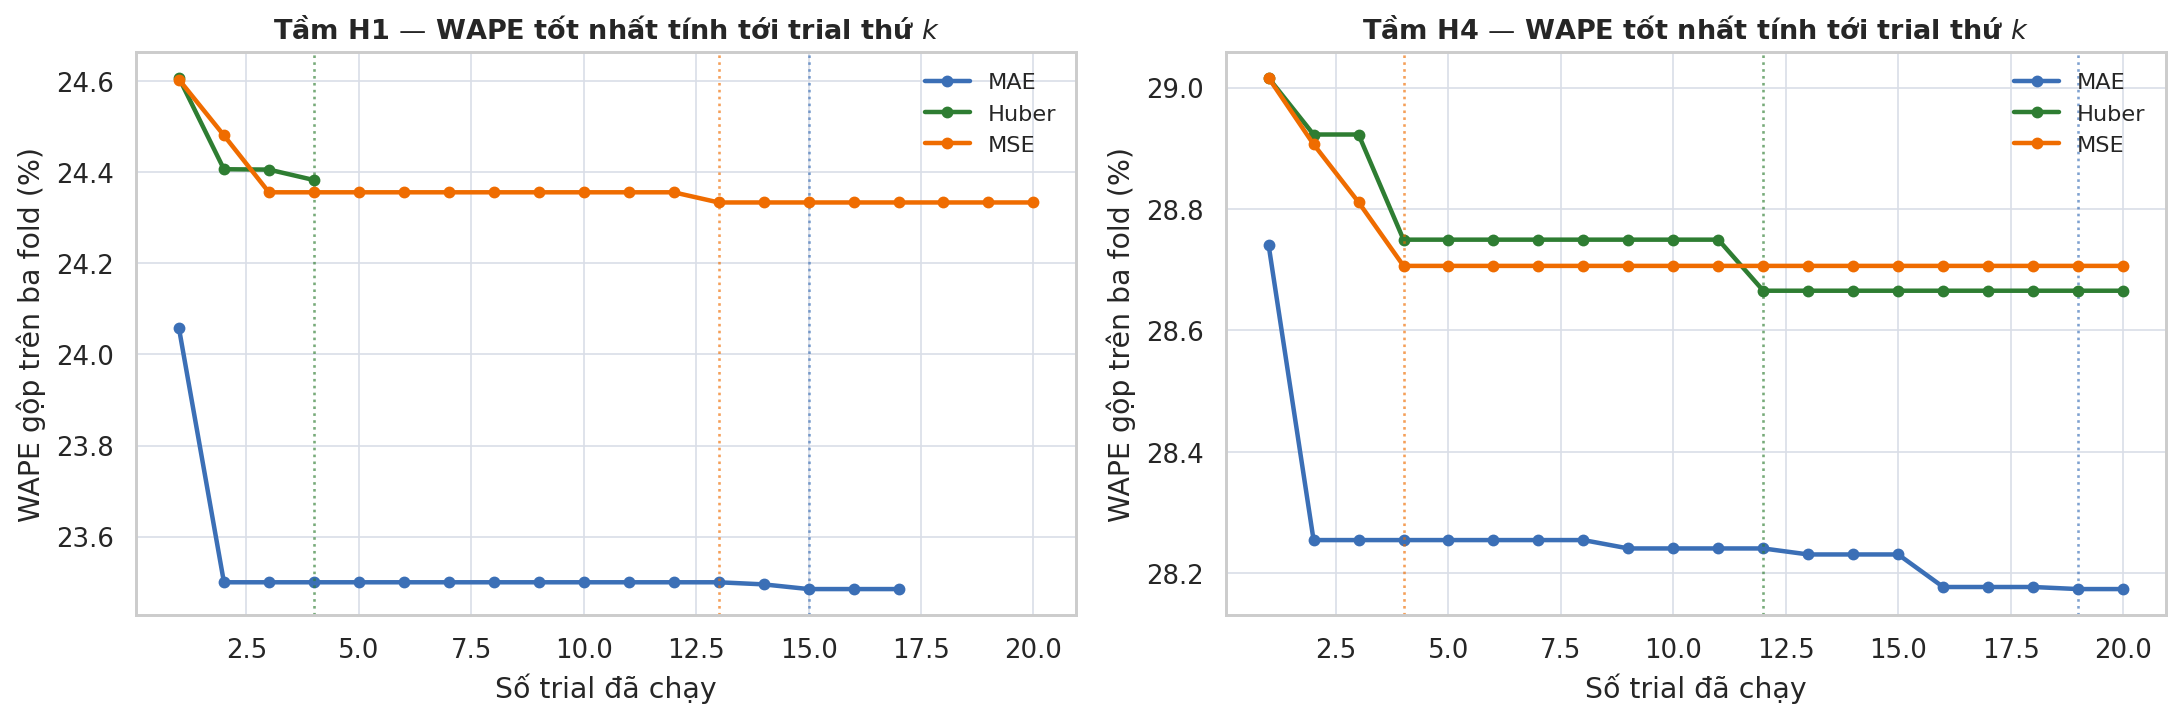

,ham_mat_mat,tam,so_trial,trial_cuoi_con_cai_thien,wape_tai_trial_20,wape_tai_trial_15,chenh_15_den_20
0,MAE,H1,17,15,23.4851,23.4851,0.000
1,Huber,H1,4,4,24.3824,24.3824,0.000
2,MSE,H1,20,13,24.3332,24.3332,0.000
3,MAE,H4,20,19,28.1740,28.2310,0.057
4,Huber,H4,20,12,28.6654,28.6654,0.000
5,MSE,H4,20,4,28.7063,28.7063,0.000


Da luu: data/model/v5/05_selected/hoi_tu_optuna_theo_trial.csv

Trial cuoi cung con cai thien, lon nhat trong 6 cau hinh: 19/20


In [22]:
# Duong hoi tu: WAPE TOT NHAT tinh toi trial thu k
fig, truc = plt.subplots(1, 2, figsize=(13, 4.4), dpi=170)
MAU = {"MAE": "#3B6FB6", "Huber": "#2E7D32", "MSE": "#EF6C00"}

bang_bao_hoa = []
for ax, tam in zip(truc, ("H1", "H4")):
    for ten in ("MAE", "Huber", "MSE"):
        ds = nhat_ky.get((ten, tam))
        if not ds:
            continue
        x = [i for i, _ in ds]
        w = [v for _, v in ds]
        tot_dan = np.minimum.accumulate(w)
        ax.plot(x, tot_dan, "-o", color=MAU[ten], linewidth=1.9, markersize=4, label=ten)

        # Trial cuoi cung con cai thien duoc: sau moc nay ngan sach da bao hoa
        cai_thien = [i for i in range(1, len(tot_dan)) if tot_dan[i] < tot_dan[i - 1] - 1e-9]
        moc = x[cai_thien[-1]] if cai_thien else 1
        bang_bao_hoa.append({
            "ham_mat_mat": ten, "tam": tam, "so_trial": len(ds),
            "trial_cuoi_con_cai_thien": moc,
            "wape_tai_trial_20": round(float(tot_dan[-1]), 4),
            "wape_tai_trial_15": round(float(tot_dan[min(14, len(tot_dan) - 1)]), 4),
        })
        ax.axvline(moc, color=MAU[ten], ls=":", lw=1.1, alpha=0.65)

    ax.set_title(f"Tầm {tam} — WAPE tốt nhất tính tới trial thứ $k$",
                 fontsize=11.5, fontweight="bold")
    ax.set_xlabel("Số trial đã chạy")
    ax.set_ylabel("WAPE gộp trên ba fold (%)")
    ax.grid(color="#D9DEE7", linewidth=0.7)
    ax.set_axisbelow(True)
    ax.legend(frameon=False, fontsize=9.5)

fig.tight_layout()
_d = RA / "hinh" / "hoi_tu_optuna_theo_trial.png"
fig.savefig(_d, bbox_inches="tight", facecolor="white")
print(f"Da luu hinh: {_d.relative_to(GOC)}")
plt.show()

df_bao_hoa = pd.DataFrame(bang_bao_hoa)
df_bao_hoa["chenh_15_den_20"] = (df_bao_hoa["wape_tai_trial_15"]
                                 - df_bao_hoa["wape_tai_trial_20"]).round(4)
display(df_bao_hoa)
df_bao_hoa.to_csv(RA / "hoi_tu_optuna_theo_trial.csv", index=False)
print(f"Da luu: {(RA / 'hoi_tu_optuna_theo_trial.csv').relative_to(GOC)}")
print(f"\nTrial cuoi cung con cai thien, lon nhat trong 6 cau hinh: "
      f"{int(df_bao_hoa['trial_cuoi_con_cai_thien'].max())}/20")

## 13. Thí nghiệm 8 — `TOP_K_FEATURES`: vì sao cắt ở 35?

Bước `05_select_features` xếp hạng đặc trưng theo Mutual Information rồi lấy $35$ cái đầu, sau đó
bổ sung lại những đặc trưng thuộc nhóm bảo vệ bị ngưỡng cắt loại. Chú thích trong code chỉ ghi
*"số lượng feature tối ưu chọn ra"* --- nói là tối ưu nhưng chưa có gì chứng minh $35$ hơn $30$
hay $40$.

Thí nghiệm này quét $K \in \{25, 30, 35, 40, 45\}$, mỗi mức lặp lại **đúng** quy tắc của bước 05
(top-$K$ theo MI, cộng lại nhóm bảo vệ bị cắt), rồi huấn luyện LightGBM với **cùng bộ siêu tham số
đã chọn** và chấm trên tập kiểm định. Giữ nguyên siêu tham số để chỉ còn một biến thay đổi là $K$.


In [23]:
# ── Chuan bi: bang xep hang dac trung va nhom bao ve, lay tu buoc 05 ─────────
diem = pd.read_csv(THU_MUC_TAP / "feature_scores.csv")
chon_05 = json.loads((THU_MUC_TAP / "selected_features.json").read_text(encoding="utf-8"))
BAO_VE = chon_05["bao_ve"]

print(f"Bang xep hang: {len(diem)} dac trung | nhom bao ve: {len(BAO_VE)}")
print(f"Buoc 05 dang chon: {len(chon_05['selected_features'])} dac trung "
      f"(35 top-MI + {len(chon_05['bao_ve_bi_top_k_cat'])} bao ve bo sung)")

def chon_theo_k(k):
    """Lap lai dung quy tac cua 05_select_features: top-K theo MI + bu nhom bao ve."""
    top = diem.head(k)["feature"].tolist()
    da_co = set(top)
    bu = [c for c in BAO_VE if c in set(diem["feature"]) and c not in da_co]
    return top + bu

# Doi chieu: K=35 phai tai lap dung danh sach 05 da ghi ra
_thu = chon_theo_k(35)
_khop = set(_thu) == set(chon_05["selected_features"])
print(f"\nTai lap K=35: {len(_thu)} dac trung | trung khop voi selected_features.json: "
      f"{'CO' if _khop else 'KHONG'}")
if not _khop:
    print("   chi co o ban tai lap:", sorted(set(_thu) - set(chon_05['selected_features'])))
    print("   chi co o ban goc    :", sorted(set(chon_05['selected_features']) - set(_thu)))

Bang xep hang: 74 dac trung | nhom bao ve: 21
Buoc 05 dang chon: 39 dac trung (35 top-MI + 4 bao ve bo sung)

Tai lap K=35: 39 dac trung | trung khop voi selected_features.json: CO


In [24]:
# ── Huan luyen tung muc K voi CUNG bo sieu tham so da chon ──────────────────
import lightgbm as lgb
import time

THAM_SO = dict(cfg["model_params"])
THAM_SO.pop("n_estimators", None)
N_CAY = int(cfg["model_params"].get("n_estimators", 650))

# Cac dac trung tai thoi diem muc tieu (_mt) luon duoc them, khong phu thuoc K
DAC_TRUNG_MT = [c for c in DAC_TRUNG if c.endswith("_mt")]
print(f"Sieu tham so: n_estimators={N_CAY}, learning_rate={THAM_SO.get('learning_rate'):.5f}")
print(f"Dac trung _mt luon them: {len(DAC_TRUNG_MT)}")

# Nhan chuan hoa va trong so — dung dung cong thuc cua notebook huan luyen
k_train_muc_tieu = np.clip(
    train_h["y_true"].to_numpy(float) / mau_chuan_hoa(train_h), 0, CLIP_DANG_DUNG)

MUC_K = [25, 30, 35, 40, 45]
ket_qua = []
for K in MUC_K:
    t0 = time.time()
    nen = chon_theo_k(K)
    cot = [c for c in nen if c in train_h.columns] + DAC_TRUNG_MT
    cot = [c for c in dict.fromkeys(cot) if c in train_h.columns and c in val_h.columns]

    med = train_h[cot].median(numeric_only=True).fillna(0.0)
    Xtr = train_h[cot].fillna(med).astype(np.float32)
    Xva = val_h[cot].fillna(med).astype(np.float32)

    m = lgb.LGBMRegressor(n_estimators=N_CAY, **THAM_SO)
    m.fit(Xtr, k_train_muc_tieu)

    y_db = giai_chuan_hoa(m.predict(Xva), CLIP_DANG_DUNG)
    w = wape(y_db)
    ket_qua.append({"top_k": K, "so_dac_trung": len(cot), "wape_val_%": round(w, 4),
                    "phut": round((time.time() - t0) / 60, 2)})
    print(f"  K={K:>3} | {len(cot):>3} cot | WAPE {w:.4f}% | {(time.time()-t0)/60:.1f} phut")

df_k = pd.DataFrame(ket_qua)
display(df_k)
df_k.to_csv(RA / "quet_top_k_features.csv", index=False)
print(f"Da luu: {(RA / 'quet_top_k_features.csv').relative_to(GOC)}")

Sieu tham so: n_estimators=600, learning_rate=0.03671
Dac trung _mt luon them: 14
  K= 25 |  34 cot | WAPE 21.8782% | 0.3 phut
  K= 30 |  36 cot | WAPE 21.8638% | 0.3 phut
  K= 35 |  39 cot | WAPE 21.8375% | 0.4 phut
  K= 40 |  39 cot | WAPE 21.8375% | 0.4 phut
  K= 45 |  39 cot | WAPE 21.8375% | 0.4 phut


,top_k,so_dac_trung,wape_val_%,phut
0,25,34,21.8782,0.32
1,30,36,21.8638,0.35
2,35,39,21.8375,0.36
3,40,39,21.8375,0.36
4,45,39,21.8375,0.36


Da luu: data/model/v5/05_selected/quet_top_k_features.csv


Da luu hinh: data/model/v5/05_selected/hinh/quet_top_k_features.png


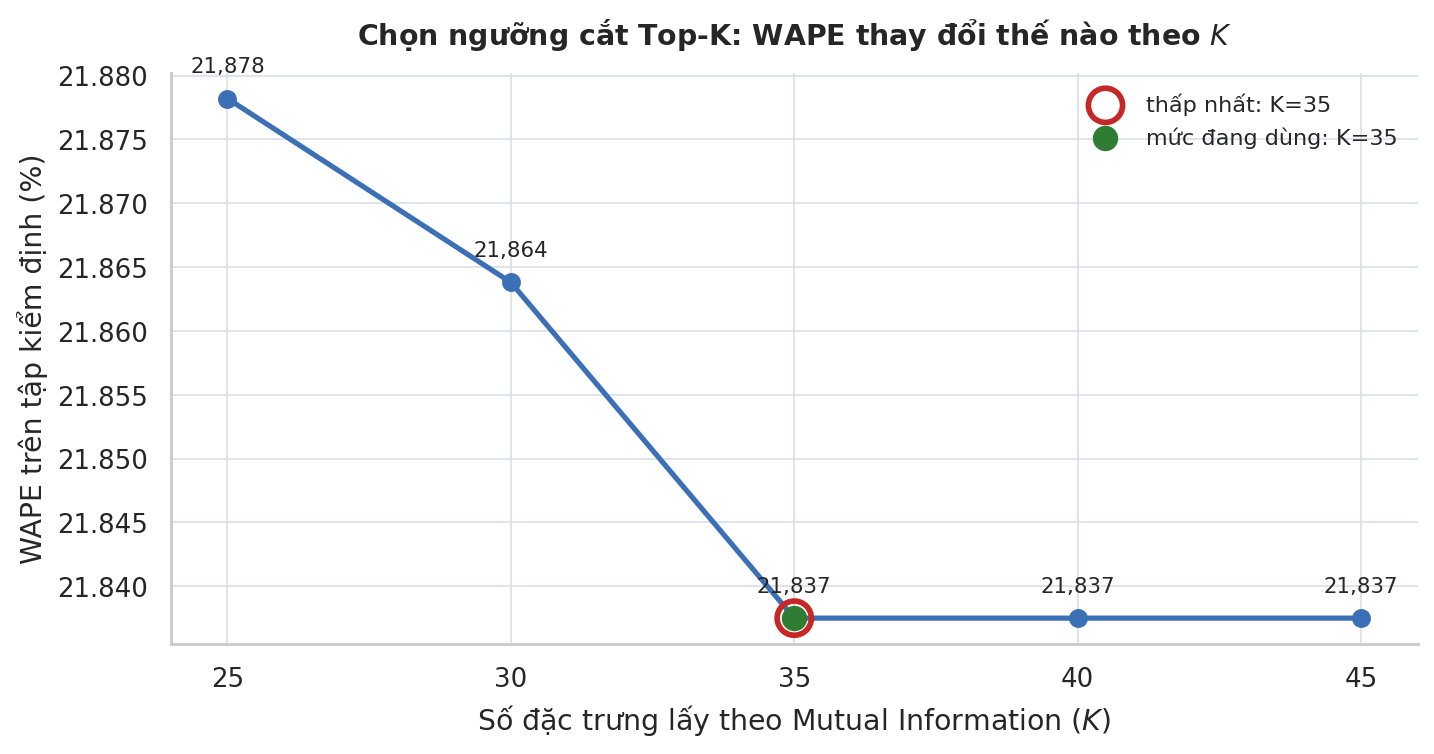


K tot nhat do duoc : 35 -> WAPE 21.8375%
K dang dung        : 35 -> WAPE 21.8375%
Chenh lech         : +0.0000 diem phan tram


In [25]:
fig, ax = plt.subplots(figsize=(8.6, 4.6), dpi=170)
ax.plot(df_k["top_k"], df_k["wape_val_%"], "-o", color="#3B6FB6",
        linewidth=2.2, markersize=7)

i_min = int(df_k["wape_val_%"].idxmin())
ax.scatter([df_k["top_k"].iloc[i_min]], [df_k["wape_val_%"].iloc[i_min]],
           s=210, facecolors="none", edgecolors="#C62828", linewidths=2.4, zorder=5,
           label=f"thấp nhất: K={df_k['top_k'].iloc[i_min]}")

i_35 = int(df_k.index[df_k["top_k"] == 35][0])
ax.scatter([35], [df_k["wape_val_%"].iloc[i_35]], s=95, color="#2E7D32", zorder=6,
           label="mức đang dùng: K=35")

for _, r in df_k.iterrows():
    ax.annotate(f"{r['wape_val_%']:.3f}".replace(".", ","),
                (r["top_k"], r["wape_val_%"]), textcoords="offset points",
                xytext=(0, 11), ha="center", fontsize=9)

ax.set_xlabel("Số đặc trưng lấy theo Mutual Information ($K$)")
ax.set_ylabel("WAPE trên tập kiểm định (%)")
ax.set_title("Chọn ngưỡng cắt Top-K: WAPE thay đổi thế nào theo $K$",
             fontsize=12, fontweight="bold", pad=12)
ax.set_xticks(df_k["top_k"])
ax.grid(color="#D9DEE7", linewidth=0.7)
ax.set_axisbelow(True)
ax.legend(frameon=False, fontsize=9.5)
for s in ("top", "right"): ax.spines[s].set_visible(False)

fig.tight_layout()
_d = RA / "hinh" / "quet_top_k_features.png"
fig.savefig(_d, bbox_inches="tight", facecolor="white")
print(f"Da luu hinh: {_d.relative_to(GOC)}")
plt.show()

_tot = df_k.loc[i_min]
_ht = df_k.loc[i_35]
print(f"\nK tot nhat do duoc : {int(_tot['top_k'])} -> WAPE {_tot['wape_val_%']:.4f}%")
print(f"K dang dung        : 35 -> WAPE {_ht['wape_val_%']:.4f}%")
print(f"Chenh lech         : {_ht['wape_val_%'] - _tot['wape_val_%']:+.4f} diem phan tram")

## Quét ngưỡng $\varepsilon$ trong mẫu số chuẩn hoá

Mẫu số là `site_scale * max(sin_elevation, eps)`. Ô dưới đây quét bảy mức `eps`
trên tập Phát triển để xem việc chọn `eps` ảnh hưởng tới phân bố hệ số $k$ ra sao.


,eps,goc_do,ty_le_bi_chan_%,k_lon_nhat,k_p99,k_p99_9
0,0.005,0.29,0.40,28.8,1.400,2.458
1,0.010,0.57,0.85,17.5,1.389,1.899
2,0.020,1.15,1.84,16.0,1.379,1.656
3,0.050,2.87,4.29,13.4,1.373,1.577
4,0.100,5.74,8.72,6.7,1.369,1.556
5,0.150,8.63,13.20,4.5,1.367,1.548
6,0.200,11.54,17.72,3.4,1.365,1.543



k p99 chi dao dong trong khoang 1.365-1.400 -> eps gan nhu khong anh huong 99% du lieu.


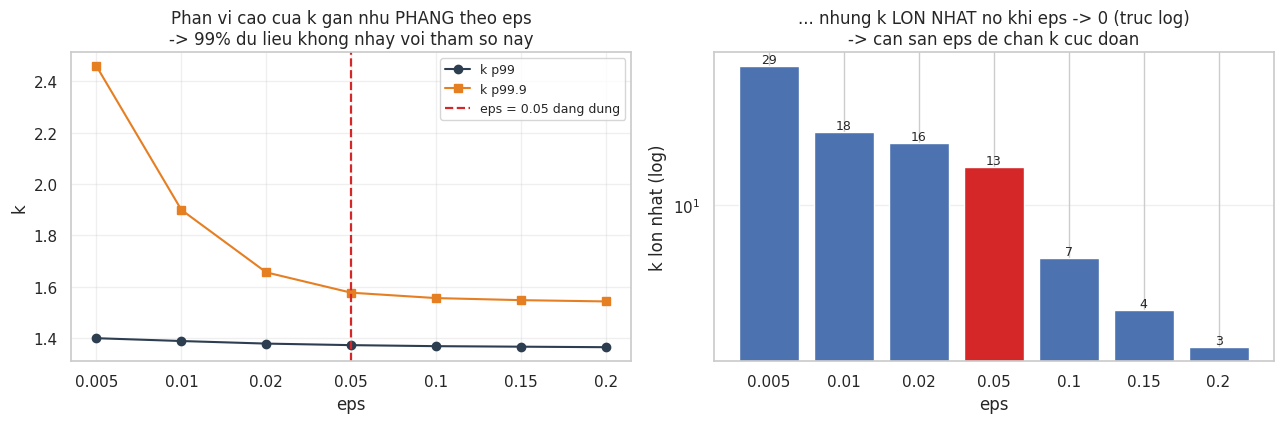

Da luu: /home/tandat/Desktop/Du_An_Tot_Nghiep_v3/data/model/v5/05_selected/quet_eps_mau_chuan_hoa.csv + .png


In [26]:
import math
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

_d = pd.read_parquet(GOC / "data/model/v5/05_selected/v5_development_selected.parquet",
                     columns=["sin_elevation", "energy_generated_kwh", "site_scale"])
_d = _d[_d["site_scale"] > 0]
_se = _d["sin_elevation"].to_numpy(); _y = _d["energy_generated_kwh"].to_numpy()
_ss = _d["site_scale"].to_numpy(); _ngay = _se > 0

_bang = []
for e in [0.005, 0.01, 0.02, 0.05, 0.10, 0.15, 0.20]:
    _mau = _ss * np.maximum(_se, e)
    _k = np.where(_mau > 0, _y / _mau, np.nan)
    _k = _k[_ngay & np.isfinite(_k)]
    _bang.append({
        "eps": e,
        "goc_do": round(math.degrees(math.asin(e)), 2),
        "ty_le_bi_chan_%": round(100 * ((_se > 0) & (_se < e)).sum() / _ngay.sum(), 2),
        "k_lon_nhat": round(float(np.nanmax(_k)), 1),
        "k_p99": round(float(np.nanpercentile(_k, 99)), 3),
        "k_p99_9": round(float(np.nanpercentile(_k, 99.9)), 3),
    })
df_eps = pd.DataFrame(_bang)
display(df_eps)
df_eps.to_csv(RA / "quet_eps_mau_chuan_hoa.csv", index=False)
print(f"\nk p99 chi dao dong trong khoang "
      f"{df_eps['k_p99'].min():.3f}-{df_eps['k_p99'].max():.3f} -> "
      f"eps gan nhu khong anh huong 99% du lieu.")

# Hinh quet eps: p99 phang (khong nhay) trong khi k_max no khi eps -> 0
fig, (_a1, _a2) = plt.subplots(1, 2, figsize=(13, 4.4))
_x = [str(v) for v in df_eps['eps']]
_a1.plot(_x, df_eps['k_p99'], 'o-', color='#2c3e50', label='k p99')
_a1.plot(_x, df_eps['k_p99_9'], 's-', color='#e67e22', label='k p99.9')
_a1.axvline(_x.index('0.05'), color='#d62728', ls='--', lw=1.6, label='eps = 0.05 dang dung')
_a1.set_title('Phan vi cao cua k gan nhu PHANG theo eps\n-> 99% du lieu khong nhay voi tham so nay')
_a1.set_xlabel('eps'); _a1.set_ylabel('k'); _a1.legend(fontsize=9); _a1.grid(alpha=0.3)
_a2.bar(_x, df_eps['k_lon_nhat'], color=['#d62728' if v == 0.05 else '#4c72b0'
                                          for v in df_eps['eps']])
_a2.set_yscale('log')
for _i, _v in enumerate(df_eps['k_lon_nhat']):
    _a2.text(_i, _v, f'{_v:,.0f}', ha='center', va='bottom', fontsize=9)
_a2.set_title('... nhung k LON NHAT no khi eps -> 0 (truc log)\n-> can san eps de chan k cuc doan')
_a2.set_xlabel('eps'); _a2.set_ylabel('k lon nhat (log)'); _a2.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(RA / 'quet_eps_mau_chuan_hoa.png', dpi=130, bbox_inches='tight')
plt.show()
print(f"Da luu: {(RA / 'quet_eps_mau_chuan_hoa.csv')} + .png")

## 14. Thí nghiệm 9 — Chồng lấn nhãn ở ranh giới fold

Ba fold được cắt **liên tục**, không chèn khoảng đệm giữa phần huấn luyện và phần kiểm định.
Hai rào chắn chống rò rỉ ở bước 02 chỉ ràng buộc **đặc trưng đầu vào**; riêng **nhãn** cần một
phép kiểm riêng.

Lý do: nhãn của một dòng huấn luyện tại thời điểm $T$ là sản lượng tại $T + h$. Với những dòng
nằm sát mốc cắt, thời điểm $T + h$ có thể đã rơi sang vùng kiểm định — tức mô hình được học một
nhãn thuộc về tương lai của chính tập dùng để chấm điểm nó.

**Cách đo.** Với mỗi fold, đọc trực tiếp tệp `fold_i_train_selected.parquet` mà bước huấn luyện
đọc vào, lấy mốc thời gian lớn nhất $T_{max}$ của phần huấn luyện. Một dòng có nhãn rơi sang
vùng kiểm định khi và chỉ khi mốc thời gian của nó lớn hơn $T_{max} - 15h$ phút. Đếm số dòng
thoả điều kiện cho cả hai tầm H1 và H4.

Phép đo không huấn luyện lại gì, chỉ đọc tệp và đếm.

In [27]:
# ── Thi nghiem 9: dem so dong huan luyen co NHAN roi sang vung kiem dinh ─────
# Doc dung cac tep fold ma buoc huan luyen doc vao, khong dung du lieu trung gian.
THU_MUC_FOLD = Path('../../data/model/v5/05_selected/time_series_folds').resolve()
BUOC_PHUT = int(CFG_GOC.data['freq_minutes'])   # 15 phut, lay tu cau hinh
CAC_TAM = [1, 4]                                 # H1 va H4

_dong = []
for _f in (1, 2, 3):
    _tr = pd.read_parquet(THU_MUC_FOLD / f'fold_{_f}_train_selected.parquet',
                          columns=['timestamp', 'site_id'])
    _va = pd.read_parquet(THU_MUC_FOLD / f'fold_{_f}_val_selected.parquet',
                          columns=['timestamp'])
    _tmax = _tr['timestamp'].max()
    _hang = {'fold': _f, 'co_tap_train': len(_tr),
             'so_tram_buoc_cuoi': int(_tr.loc[_tr['timestamp'].eq(_tmax), 'site_id'].nunique()),
             'train_den': _tmax, 'val_tu': _va['timestamp'].min()}
    for _h in CAC_TAM:
        _bien = _tmax - pd.Timedelta(minutes=BUOC_PHUT * _h)
        _n = int((_tr['timestamp'] > _bien).sum())
        _hang[f'chong_lan_h{_h}'] = _n
        _hang[f'ty_le_h{_h}_%'] = round(100.0 * _n / len(_tr), 4)
    _dong.append(_hang)
    del _tr, _va

kq_chong_lan = pd.DataFrame(_dong)

print("--- THI NGHIEM 9: CHONG LAN NHAN O RANH GIOI FOLD ---")
print(f"Buoc thoi gian: {BUOC_PHUT} phut | cac tam do: {CAC_TAM}\n")
print(kq_chong_lan[['fold', 'co_tap_train', 'chong_lan_h1', 'chong_lan_h4',
                    'ty_le_h4_%']].to_string(index=False))

_xau = kq_chong_lan.loc[kq_chong_lan['ty_le_h4_%'].idxmax()]
print(f"\nTruong hop xau nhat: fold {int(_xau['fold'])} o tam H4 — "
      f"{int(_xau['chong_lan_h4']):,} dong tren tong {int(_xau['co_tap_train']):,}"
      f" = {_xau['ty_le_h4_%']:.4f}%")

# Doi chieu noi tai: o tam H1 chi dung MOT buoc cuoi bi chong lan, nen so dong
# phai bang dung so tram con hoat dong tai buoc do. Neu lech thi luoi khong deu.
_khop = (kq_chong_lan['chong_lan_h1'] == kq_chong_lan['so_tram_buoc_cuoi']).all()
print(f"Doi chieu H1 == so tram tai buoc cuoi: {'DAT' if _khop else 'SAI'} "
      f"({list(kq_chong_lan['chong_lan_h1'])} vs {list(kq_chong_lan['so_tram_buoc_cuoi'])})")

kq_chong_lan.to_csv(f'{OUTPUT_DIR}/thuc_nghiem_chong_lan_nhan_fold.csv', index=False)
print(f"\nDa ghi: {OUTPUT_DIR}/thuc_nghiem_chong_lan_nhan_fold.csv")

--- THI NGHIEM 9: CHONG LAN NHAN O RANH GIOI FOLD ---
Buoc thoi gian: 15 phut | cac tam do: [1, 4]

 fold  co_tap_train  chong_lan_h1  chong_lan_h4  ty_le_h4_%
    1        233244            30           120      0.0514
    2        839349            39           156      0.0186
    3       1550856            42           168      0.0108

Truong hop xau nhat: fold 1 o tam H4 — 120 dong tren tong 233,244 = 0.0514%
Doi chieu H1 == so tram tai buoc cuoi: DAT ([30, 39, 42] vs [30, 39, 42])

Da ghi: ../../data/model/v5/05b_thuc_nghiem_tham_so/thuc_nghiem_chong_lan_nhan_fold.csv


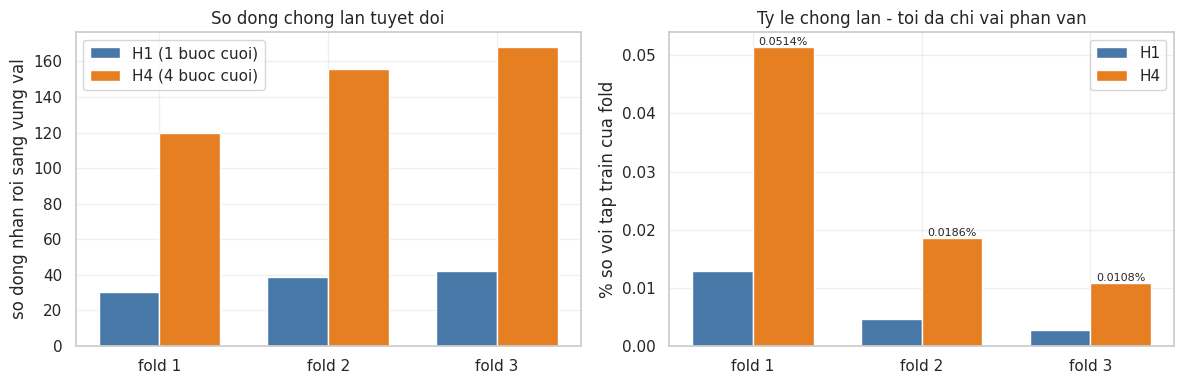

Da luu ../../data/model/v5/05b_thuc_nghiem_tham_so/tn9_chong_lan_nhan_fold.png


In [28]:
# Hinh TN9: chong lan nhan o ranh gioi fold - nho den muc nao
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
_x = np.arange(len(kq_chong_lan))
ax[0].bar(_x - 0.18, kq_chong_lan['chong_lan_h1'], 0.36, label='H1 (1 buoc cuoi)', color='#4878a8')
ax[0].bar(_x + 0.18, kq_chong_lan['chong_lan_h4'], 0.36, label='H4 (4 buoc cuoi)', color='#e67e22')
ax[0].set_xticks(_x, [f"fold {int(f)}" for f in kq_chong_lan['fold']])
ax[0].set_ylabel('so dong nhan roi sang vung val')
ax[0].set_title('So dong chong lan tuyet doi')
ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].bar(_x - 0.18, kq_chong_lan['ty_le_h1_%'], 0.36, label='H1', color='#4878a8')
ax[1].bar(_x + 0.18, kq_chong_lan['ty_le_h4_%'], 0.36, label='H4', color='#e67e22')
for _i in _x:
    ax[1].text(_i + 0.18, kq_chong_lan['ty_le_h4_%'].iloc[_i], f"{kq_chong_lan['ty_le_h4_%'].iloc[_i]:.4f}%",
               ha='center', va='bottom', fontsize=8)
ax[1].set_xticks(_x, [f"fold {int(f)}" for f in kq_chong_lan['fold']])
ax[1].set_ylabel('% so voi tap train cua fold')
ax[1].set_title('Ty le chong lan - toi da chi vai phan van')
ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.savefig(f'{OUTPUT_DIR}/tn9_chong_lan_nhan_fold.png', dpi=130); plt.show()
print(f"Da luu {OUTPUT_DIR}/tn9_chong_lan_nhan_fold.png")

## 15. Thí nghiệm 10 — Đo nhiễu huấn luyện (seed sweep)

Mọi kết luận *"chênh lệch nằm trong biên nhiễu"* ở các thí nghiệm phía trên cần một con số
chuẩn: nhiễu huấn luyện là bao nhiêu? Cách đo giáo khoa: giữ nguyên **toàn bộ** cấu hình
(dữ liệu, đặc trưng, tham số, quy trình chấm), chỉ đổi **seed** (chi phối mẫu con và tính
ngẫu nhiên của LightGBM) — độ phân tán WAPE thu được chính là nhiễu.

Quy ước đọc: chênh lệch giữa hai cấu hình chỉ được coi là **khác biệt thật** khi vượt
khoảng ~3 lần std đo ở đây; nhỏ hơn thì kết luận đúng là "không phân biệt được".

  seed 42: WAPE 22.5607%
  seed 43: WAPE 22.7059%
  seed 44: WAPE 22.5576%
  seed 45: WAPE 22.6185%
  seed 46: WAPE 22.6818%
  seed 47: WAPE 22.6336%

NHIEU HUAN LUYEN: trung binh 22.6264% | std 0.0609 | bien do 0.1483 diem
Quy uoc: chenh lech < ~0.18 diem (3 x std) => KHONG PHAN BIET DUOC voi nhieu.


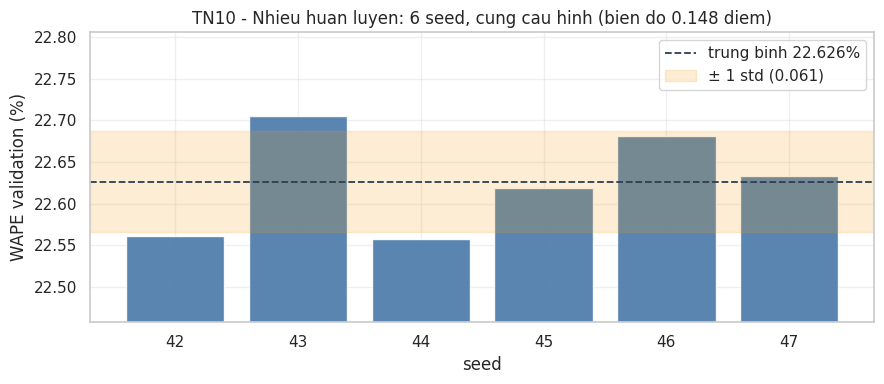

Da luu ../../data/model/v5/05b_thuc_nghiem_tham_so/tn10_nhieu_huan_luyen.png + .csv


In [29]:
# TN10: seed sweep - cung cau hinh, chi doi seed. Doc lap voi pipeline ctx.
import matplotlib.pyplot as plt

_SEL = str(ctx.paths.stage('s07_selected')) if 'ctx' in dir() else '../../data/model/v5/05_selected'
_COT_MT = ['solar_elevation','solar_azimuth','azimuth_sin','azimuth_cos','sin_elevation',
           'ghi_cs','ky_vong','ty_le_bao_hoa','minute_of_day','hour','hour_sin','hour_cos',
           'doy_sin','doy_cos']
import json as _json
_f39 = _json.load(open(f'{_SEL}/selected_features.json'))['selected_features']

def _nap_tn10(ten):
    _d = pd.read_parquet(f'{_SEL}/{ten}.parquet')
    _d = _d[(_d['exclude_from_training'] == False) & (_d['has_complete_history_features'] == True)]
    _d = _d.dropna(subset=['energy_generated_kwh'])
    _d = _d[~_d['site_id'].isin([19, 24])].sort_values(['site_id', 'timestamp']).reset_index(drop=True)
    _g = _d.groupby('site_id')
    _d['y_true'] = _g['energy_generated_kwh'].shift(-1)
    for _c in _COT_MT:
        if _c in _d.columns: _d[f'{_c}_mt'] = _g[_c].shift(-1)
    _d['nhan_src'] = _g['energy_source'].shift(-1); _d['nhan_day'] = _g['is_daylight'].shift(-1)
    _d = _d.dropna(subset=['y_true'])
    _d = _d[(_d['site_scale'] > 0) & (_d['sin_elevation'] > 0.05)]
    _m = _d['nhan_src'].astype(str).eq('measured') & _d['nhan_day'].astype('boolean').fillna(False).astype(bool)
    return _d[_m]

_tr10 = _nap_tn10('v5_train_selected'); _va10 = _nap_tn10('v5_val_selected')
_mau_tr = (_tr10['site_scale'] * np.clip(_tr10['sin_elevation'], 0.05, None)).to_numpy()
_CLIP10 = float(pd.Series(np.clip(_tr10['y_true'].to_numpy() / _mau_tr, 0, None)).quantile(0.99))
_FE10 = [c for c in _f39 if c in _tr10.columns] + [f'{c}_mt' for c in _COT_MT if f'{c}_mt' in _tr10.columns]
_MED10 = _tr10[_FE10].median(numeric_only=True).fillna(0.0)
_Xva = _va10[_FE10].fillna(_MED10).astype(np.float32)
_mau_va = (_va10['site_scale'] * np.clip(_va10['sin_elevation'], 0.05, None)).to_numpy()
_yva = _va10['y_true'].to_numpy(); _tran_va = _va10['tran_cong_suat'].to_numpy()

from lightgbm import LGBMRegressor as _LGB
_kq10 = {}
for _seed in (42, 43, 44, 45, 46, 47):
    _idx = _tr10.sample(n=min(300_000, len(_tr10)), random_state=_seed).index
    _X = _tr10.loc[_idx, _FE10].fillna(_MED10).astype(np.float32)
    _k = np.clip(np.clip(_tr10.loc[_idx, 'y_true'].to_numpy()
                         / _mau_tr[_tr10.index.get_indexer(_idx)], 0, None), 0, _CLIP10)
    _m10 = _LGB(objective='l1', random_state=_seed, verbosity=-1, n_jobs=6, max_bin=127,
                force_col_wise=True, deterministic=True,
                n_estimators=200, learning_rate=0.08, num_leaves=63, min_child_samples=40)
    _m10.fit(_X, _k.astype(np.float32), sample_weight=(1.0 + _k).astype(np.float32),
             categorical_feature=[c for c in _FE10 if c.endswith('_enc')])
    _yp = np.minimum(np.clip(_m10.predict(_Xva), 0, _CLIP10) * _mau_va, _tran_va * 1.02)
    _kq10[_seed] = float(np.abs(_yp - _yva).sum() / np.abs(_yva).sum() * 100)
    print(f'  seed {_seed}: WAPE {_kq10[_seed]:.4f}%')

_v = np.array(list(_kq10.values()))
_std = _v.std(ddof=1); _bd = _v.max() - _v.min()
print(f'\nNHIEU HUAN LUYEN: trung binh {_v.mean():.4f}% | std {_std:.4f} | bien do {_bd:.4f} diem')
print(f'Quy uoc: chenh lech < ~{3*_std:.2f} diem (3 x std) => KHONG PHAN BIET DUOC voi nhieu.')

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar([str(s) for s in _kq10], _v, color='#4878a8', alpha=0.9)
ax.axhline(_v.mean(), color='#2c3e50', ls='--', lw=1.3, label=f'trung binh {_v.mean():.3f}%')
ax.axhspan(_v.mean() - _std, _v.mean() + _std, color='#f39c12', alpha=0.18, label=f'± 1 std ({_std:.3f})')
ax.set_ylim(_v.min() - 0.1, _v.max() + 0.1)
ax.set_xlabel('seed'); ax.set_ylabel('WAPE validation (%)')
ax.set_title(f'TN10 - Nhieu huan luyen: 6 seed, cung cau hinh (bien do {_bd:.3f} diem)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(f'{OUTPUT_DIR}/tn10_nhieu_huan_luyen.png', dpi=130); plt.show()
pd.DataFrame({'seed': list(_kq10), 'wape_val_%': _v}).to_csv(
    f'{OUTPUT_DIR}/tn10_nhieu_huan_luyen.csv', index=False)
print(f"Da luu {OUTPUT_DIR}/tn10_nhieu_huan_luyen.png + .csv")

## 16. Thí nghiệm 11 — Ablation trọng số mẫu: `1+k` vs tắt vs `mẫu_số`

Bổ sung cho Thí nghiệm 4 (sweep α): so ba CƠ CHẾ trọng số trên cùng mẫu, cùng seed —
đo cả WAPE theo vùng và thiên lệch (ME), thứ mà WAPE tổng không nhìn thấy:

- **A. `w = 1 + k`** (đang dùng): nhấn vùng đỉnh theo nhãn — kỳ vọng tốt ở đỉnh, trả giá bias dương
- **B. `w = 1`**: tắt hẳn
- **C. `w = mẫu_số`**: trọng số tất định (site_scale × sin_elevation) — thẳng hàng toán học với WAPE kWh, không dính nhãn

**Chạy SAU Thí nghiệm 10** (tái dùng dữ liệu `_tr10/_va10`).

                bien_the  wape_%  wape_dinh_%  wape_thap_%  ME_kwh
A: w = 1 + k (dang dung) 22.5607      12.7832      97.2354  0.3714
          B: w = 1 (tat) 22.3219      14.2323      86.3357  0.1258
C: w = mau_so (tat dinh) 22.2274      14.4966      84.2362  0.0742

Doc cung TN10: khac biet < ~0.18 diem la trong bien nhieu.


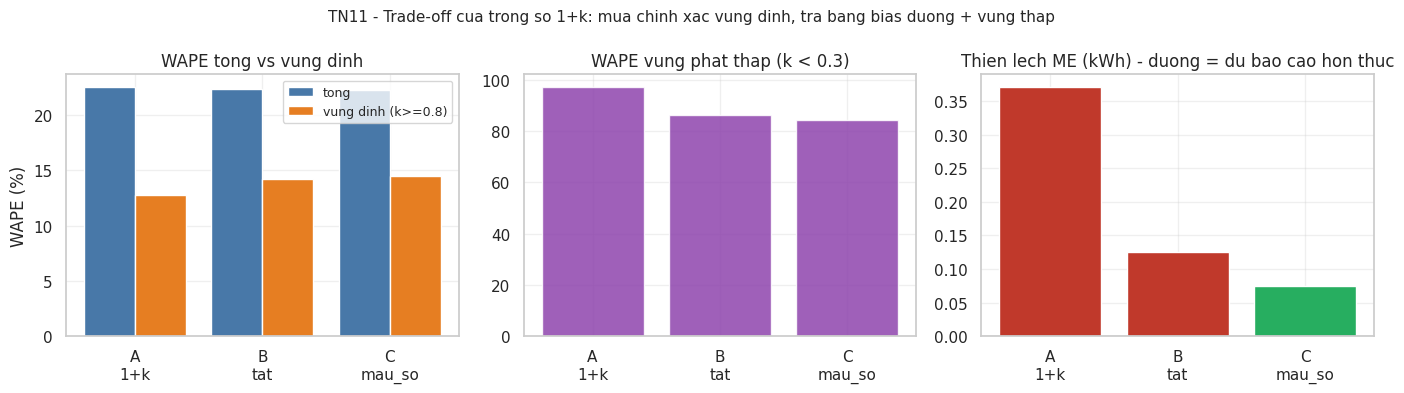

Da luu ../../data/model/v5/05b_thuc_nghiem_tham_so/tn11_ablation_trong_so.png + .csv


In [30]:
# TN11: ablation ba co che trong so. Yeu cau da chay TN10 (tai dung _tr10/_va10).
import matplotlib.pyplot as plt
assert '_tr10' in dir(), 'Chay Thi nghiem 10 truoc de co du lieu _tr10/_va10'

_idx11 = _tr10.sample(n=min(300_000, len(_tr10)), random_state=42).index
_X11 = _tr10.loc[_idx11, _FE10].fillna(_MED10).astype(np.float32)
_k11 = np.clip(np.clip(_tr10.loc[_idx11, 'y_true'].to_numpy()
                       / _mau_tr[_tr10.index.get_indexer(_idx11)], 0, None), 0, _CLIP10)
_mau11 = _mau_tr[_tr10.index.get_indexer(_idx11)]
_k_va = _yva / _mau_va
_dinh = _k_va >= 0.8
_thap = _k_va < 0.3

def _wape11(_yp, _m):
    return float(np.abs(_yp[_m] - _yva[_m]).sum() / np.abs(_yva[_m]).sum() * 100)

_bien_the = {
    'A: w = 1 + k (dang dung)': (1.0 + _k11).astype(np.float32),
    'B: w = 1 (tat)': np.ones(len(_idx11), np.float32),
    'C: w = mau_so (tat dinh)': (_mau11 / _mau11.mean()).astype(np.float32),
}
_kq11 = []
for _ten11, _w11 in _bien_the.items():
    _m11 = _LGB(objective='l1', random_state=42, verbosity=-1, n_jobs=6, max_bin=127,
                force_col_wise=True, deterministic=True,
                n_estimators=200, learning_rate=0.08, num_leaves=63, min_child_samples=40)
    _m11.fit(_X11, _k11.astype(np.float32), sample_weight=_w11,
             categorical_feature=[c for c in _FE10 if c.endswith('_enc')])
    _yp11 = np.minimum(np.clip(_m11.predict(_Xva), 0, _CLIP10) * _mau_va, _tran_va * 1.02)
    _kq11.append({'bien_the': _ten11,
                  'wape_%': _wape11(_yp11, np.ones(len(_yva), bool)),
                  'wape_dinh_%': _wape11(_yp11, _dinh),
                  'wape_thap_%': _wape11(_yp11, _thap),
                  'ME_kwh': float((_yp11 - _yva).mean())})
_b11 = pd.DataFrame(_kq11)
print(_b11.round(4).to_string(index=False))
print(f"\nDoc cung TN10: khac biet < ~{3*_std:.2f} diem la trong bien nhieu.")

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
_x11 = np.arange(3); _nhan11 = ['A\n1+k', 'B\ntat', 'C\nmau_so']
ax[0].bar(_x11 - 0.2, _b11['wape_%'], 0.4, label='tong', color='#4878a8')
ax[0].bar(_x11 + 0.2, _b11['wape_dinh_%'], 0.4, label='vung dinh (k>=0.8)', color='#e67e22')
ax[0].set_xticks(_x11, _nhan11); ax[0].set_ylabel('WAPE (%)')
ax[0].set_title('WAPE tong vs vung dinh'); ax[0].legend(fontsize=9); ax[0].grid(alpha=0.3)
ax[1].bar(_nhan11, _b11['wape_thap_%'], color='#8e44ad', alpha=0.85)
ax[1].set_title('WAPE vung phat thap (k < 0.3)'); ax[1].grid(alpha=0.3)
ax[2].bar(_nhan11, _b11['ME_kwh'], color=['#c0392b' if v > 0.1 else '#27ae60' for v in _b11['ME_kwh']])
ax[2].axhline(0, color='k', lw=0.8)
ax[2].set_title('Thien lech ME (kWh) - duong = du bao cao hon thuc'); ax[2].grid(alpha=0.3)
fig.suptitle('TN11 - Trade-off cua trong so 1+k: mua chinh xac vung dinh, tra bang bias duong + vung thap', fontsize=11)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/tn11_ablation_trong_so.png', dpi=130); plt.show()
_b11.to_csv(f'{OUTPUT_DIR}/tn11_ablation_trong_so.csv', index=False)
print(f"Da luu {OUTPUT_DIR}/tn11_ablation_trong_so.png + .csv")

## 17. Đối chiếu văn liệu: các paper đã trích trong `.tex` hợp lệ hóa tham số bằng cách nào

Mục này trả lời câu hỏi phản biện *"phương pháp hợp lệ hóa tham số của nhóm có theo chuẩn
văn liệu không?"* — đối chiếu từng paper ĐANG được trích trong `reports/Section6_thamkhao.tex`
với cách làm của notebook này.

| Paper (bibkey trong .tex) | Tham số liên quan | Họ hợp lệ hóa bằng cách nào | Mình làm tương ứng |
|---|---|---|---|
| `haurwitz1945` | Hằng số 1098 / 0.059 của `ghi_cs` | **Fit thực nghiệm** trên dữ liệu quan trắc (hồi quy insolation theo độ che phủ mây) — hằng số suy từ dữ liệu đo, không phải tiên nghiệm | 05f TN2 tái lập cả hai hằng số trên dữ liệu 42 trạm; 03_2b đối chiếu bản pvlib trùng 0.0000 W/m² |
| `engerer2014kpv` | Chỉ số trời quang / mẫu số chuẩn hóa (họ K_PV) | **So sánh nhiều định nghĩa chỉ số** trên dữ liệu PV thật, đánh giá bằng tính chất phân phối của chỉ số | 05c đối đầu 9 phương án mẫu số trên validation, cùng seed cùng tập chấm |
| `lonij2012tucson` | Mẫu số = phân vị sản lượng đo (gốc của phương án `lonij` và tư tưởng `site_scale`) | **Phân tích fleet thật** (80 hệ rooftop) — mẫu số suy từ phân vi dữ liệu đo của chính hệ thống | `site_scale` = phân vị 0.99 tập train; 05c chứng minh phương án dự án thắng phương án gốc của paper 3,4 điểm WAPE |
| `li2025gmmif` | Kiến trúc GMM+IF, ngưỡng hợp nhất 0.65 | **Thực nghiệm phát hiện bất thường** trên dữ liệu PV, đánh giá bằng tiêu chí thống kê | Doc 2026_08_06 mục 4 + 05d (rào chắn vật lý, quét hệ số m) |
| `kim2019missing` | Chiến lược điền khuyết | **Quét nhiều phương pháp điền khuyết rồi đo TÁC ĐỘNG lên sai số dự báo** — đúng triết lý "tham số phải được đánh giá qua hậu quả cuối" | Chính là khung của notebook 05b: quét giá trị → train lại → đo WAPE |
| `zhang2015metrics`, `marquez2013skill`, `kolassa2007mad`, `nguyen2026meta`, `pin2025wape`, `wwrp2009verif` | Lựa chọn thước đo (WAPE, skill score) | **Khảo cứu/đề xuất bộ metric chuẩn** cho dự báo mặt trời | WAPE làm thước chính (kolassa2007mad biện minh MAD/mean thay MAPE), skill vs persistence ở 06/07 |

**Nhận xét tổng**: các paper trên dùng đúng 3 họ phương pháp — (A) fit thực nghiệm trên dữ
liệu đo, (B) benchmark đa phương án bằng error metrics, (C) phân tích ngưỡng/độ nhạy.
Notebook này dùng (B)+(C) trên validation, **cộng thêm hai thứ nhiều paper không có**:
sàn nhiễu đo bằng seed-sweep (TN10) và ablation cơ chế (TN11).

### Paper ĐANG DÙNG trong pipeline nhưng CHƯA có trong `.tex` — cần bổ sung citation

| Thiếu | Dùng cho | Nguồn đầy đủ (verify trước khi đưa vào .tex) |
|---|---|---|
| Kwarikunda & Chiguvare (2021) | Ngưỡng góc cao 10° khi tính `cs_factor` (comment 03_2) | *Performance Analysis of Clear Sky GHI Models...*, Wiley, DOI 10.1155/2021/4369959 |
| Mabasa et al. (2021) | Cùng ngưỡng 10° | *Energies* 14(9):2583, MDPI |
| Reno, Hansen & Stein (2012) | Đánh giá/cài đặt Haurwitz (comment 03_2 + 05f) | Sandia SAND2012-2389 |
| Reda & Andreas (2004) | Thuật toán SPA (pvlib) — hình học v5 | *Solar Energy* 76(5), NREL SPA |
| Holmgren, Hansen & Mikofski (2018) | Thư viện pvlib | *JOSS* 3(29):884 |
| Tukey (1977) | Hệ số k=3 của rào IQR ("far-out fences") | *Exploratory Data Analysis*, Addison-Wesley |
| Branco/Torgo/Ribeiro (2016); Yang et al. (2021); Steininger et al. (2021) | Khung relevance-weighting cho `w = 1 + α·k` (TN4/TN11) | ACM CSUR 49(2); ICML 2021; *Machine Learning* 110 |

*Lưu ý quy trình: mọi mục ở bảng "cần bổ sung" phải verify năm/tập/trang nguyên văn
trước khi đưa vào `.tex` (theo chuẩn kiểm citation của nhóm).*

### Tham số KHÔNG có tiền lệ trực tiếp — chứng minh theo đúng KHUÔN ablation của văn liệu

Bốn tham số dưới đây là đề xuất của nhóm (không paper nào cho sẵn con số), nhưng cách
chứng minh đi theo đúng khuôn mẫu mà các paper lớn dùng cho tham số của chính họ:

| Tham số | Thực nghiệm trong bộ notebook | Paper dùng cùng khuôn chứng minh |
|---|---|---|
| `w = 1 + α·k` (α=1) | TN4 quét α + TN11 ablation A/B/C + TN10 sàn nhiễu seed | Focal Loss (Lin et al. 2017): γ=2 chọn bằng bảng ablation, báo cáo "robust với γ∈[0.5,5]" — đúng dạng kết luận "không nhạy" của TN4; DenseWeight (Steininger et al. 2021, *Machine Learning* 110): quét α, đánh giá RMSE theo bin **trung bình trên 20 lần chạy lặp** (tiền lệ trực tiếp của TN10), và kết luận **α=1 hiệu quả nhất — trùng đúng α=1 của dự án** |
| Trần nhãn k = q99 train | TN2 quét `k_target_max` + plot phân phối k trong 06_1 | Winsorization (quy ước thống kê) + khuôn "quét → đo hậu quả dự báo" của Kim 2019 |
| Hệ số trần công suất 1.02 | 05f TN1: phân phối tỷ lệ đo/trần, % vượt 1.00/1.02/1.05 | Cùng logic Lonij 2012: ngưỡng đặt tại đuôi phân phối THỰC ĐO của chính hệ thống |
| Ngưỡng hợp nhất GMM-IF 0.65 | 05d quét hệ số + rào chắn vật lý | Li et al. 2025 cũng chọn ngưỡng bằng thực nghiệm trên dữ liệu của họ — nhóm lặp lại QUY TRÌNH, không chép số |

**Câu phát biểu chuẩn khi bảo vệ:** tham số dạng này trong ML không được chứng minh bằng
toán ở bất kỳ paper nào — chuẩn công bố là *bảng ablation + quét độ nhạy trên dữ liệu của
chính tác giả*. Bộ 05x làm đúng chuẩn đó, cộng thêm sàn nhiễu TN10 để phân biệt khác biệt
thật với nhiễu huấn luyện (điều đa số paper không đo).


- Lin et al. 2017 (Focal Loss): tham số γ/α chọn qua bảng ablation; Figure 1 vẽ HỌ ĐƯỜNG
  CONG loss theo các giá trị γ (0, 0.5, 1, 2, 5) — khuôn "quét tham số vẽ thành hình";
  kết luận gốc: "fairly robust to exact γ/α settings", γ robust trong [0.5, 5].
- Steininger et al. 2021 (DenseWeight): hình đánh giá là mean RMSE per test bin **over 20
  runs** — tức paper chuẩn về trọng số mẫu CÓ đo nhiễu lặp như TN10; α=1 là giá trị họ
  thấy hiệu quả nhất.
- Số Figure/Table chính xác của từng hình DenseWeight chưa kiểm từng trang → khi đưa vào
  `.tex` chỉ trích KẾT LUẬN + tên paper, không tự bịa số Figure (theo chuẩn verify nguyên
  văn của nhóm).